# Results FCBG Connectome Registration

Visualisation of metabolite concentration maps (MRSI) overlaid on the T1w UNI-DEN background.


In [38]:
from data_utils import (
    img_info,
    rank_metabolites_by_snr,
    segment_t1w,segment_t1w_atlas)
from registration_utils import (
    register_t1w_to_mrsi_weighted,
    apply_transform_to_metabolite,
    apply_transform_all_metabolites,
    compute_registration_metrics,
    
)
from plot_utils import (
    plot_single_overlay,
    plot_support_mask,
    plot_coverage_grid,
    plot_mrsi_mosaic,
    plot_mrsi_combined,
    build_coverage_widget,
    plot_t1w_mrs_comparison,
    plot_snr_ranking,
    plot_water_mask_comparison,
    plot_registration_comparison,
    plot_registration_methods_comparison,
    plot_registration_target_comparison,
    plot_coverage_registration_comparison,
    compare_registration_coverage,
    plot_sum_registration_comparison,
    plot_inverse_registration_panels,
    compare_inverse_registration_pair,
    plot_total_pipeline_comparison,
    plot_registration_metrics,
    plot_final_registration_mosaic,
    plot_segmentation,
    plot_atlas_segmentation,
    plot_mrsi_sum_mask_contours,
    plot_bet_vs_water_mask,
)
from main import t1w_img,mrs_files,mrs_example, T1W_PATH,MRS_DIR,SUBJ,SES, SUM_NAME, t1w_ds_img

## 1 – Sanity check: image shapes & voxel sizes

In [39]:

img_info(t1w_img,     "T1w UNI-DEN")
img_info(mrs_example, f"MRS – {mrs_files[0]}")

T1w UNI-DEN
  shape      : (224, 272, 288)
  voxel size : [0.8   0.799 0.799] mm
  dtype      : int16

MRS – sub-01_ses-01_acq-OrigRes_desc-2HG_mrsi.nii.gz
  shape      : (74, 74, 37)
  voxel size : [2.973 2.973 2.973] mm
  dtype      : float32



## 2 – Single metabolite overlay on T1w

`plot_single_overlay` canonicalizes orientations, resamples MRSI to T1 grid, and plots 3 orthogonal views.  
Change `METABOLITE` to any label available in `mrs_files`.

Showing: sub-01_ses-01_acq-OrigRes_desc-NAA_mrsi.nii.gz


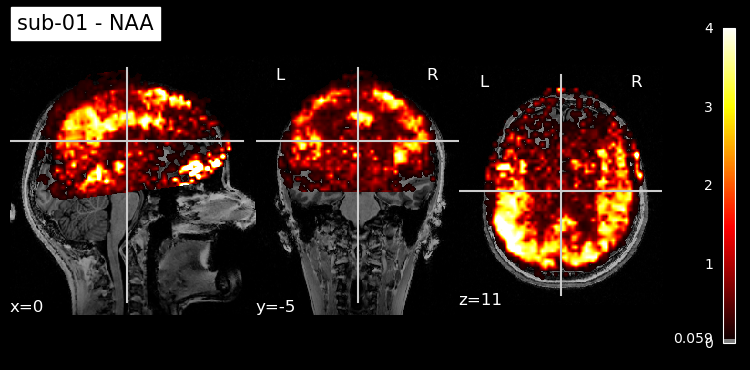

  Brain coverage: 18.6%


In [40]:
METABOLITE = "NAA"   # change to any metabolite label (e.g. "Cr", "Glu", "GABA")
match = [f for f in mrs_files if f"desc-{METABOLITE}_" in f]
if not match:
    print(f"No file found for metabolite '{METABOLITE}'")
else:
    print(f"Showing: {match[0]}")
    plot_single_overlay(match[0], T1W_PATH, MRS_DIR, subj=SUBJ)


## 3 – Coverage check:

Overlay several metabolite maps on the T1w in a single figure  so we can directly compare spatial coverage across metabolites.

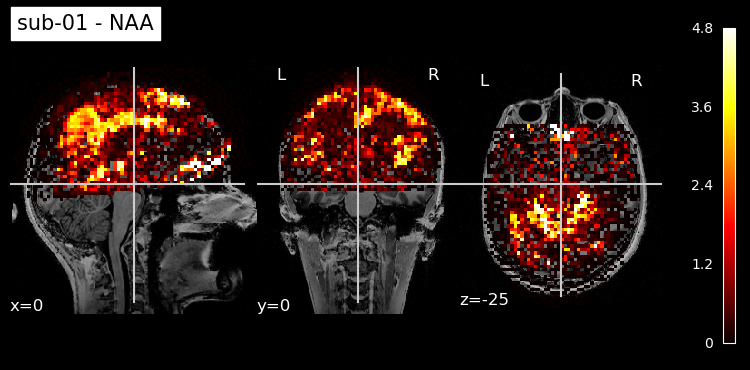

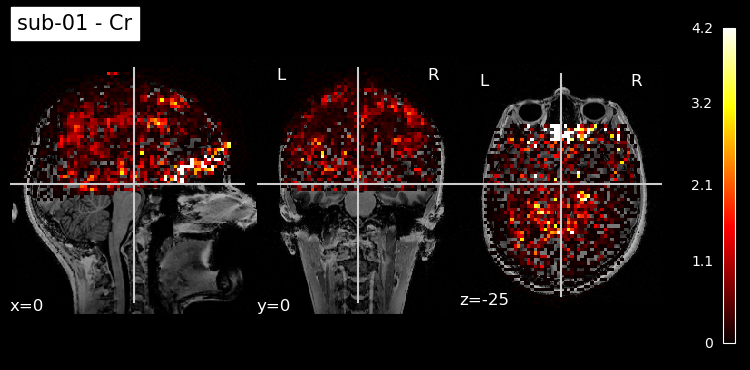

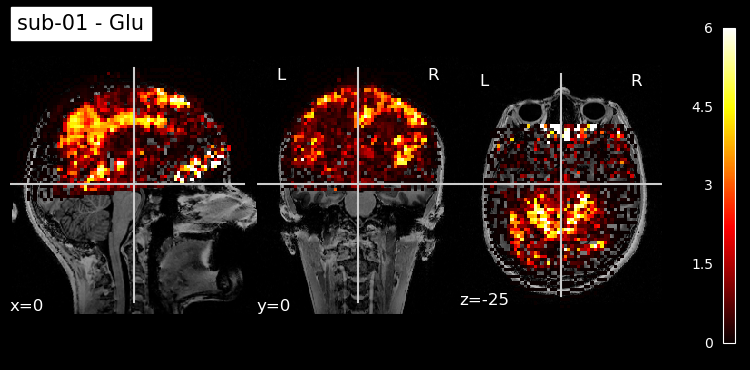

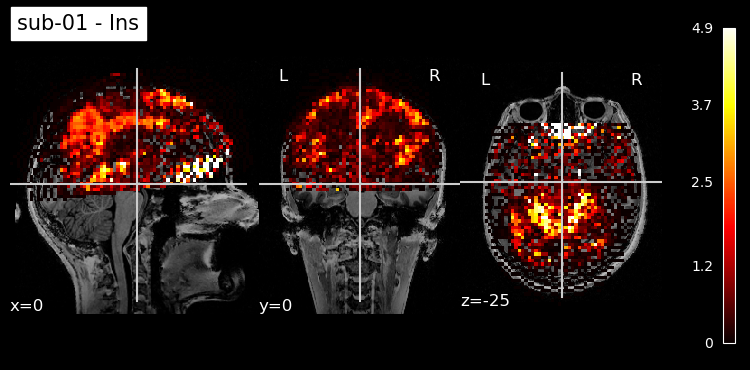

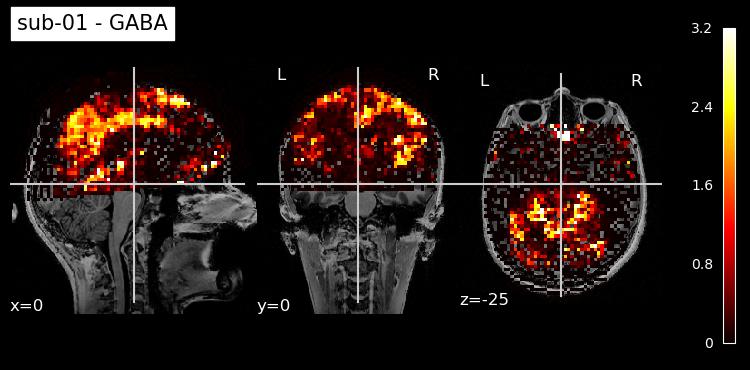

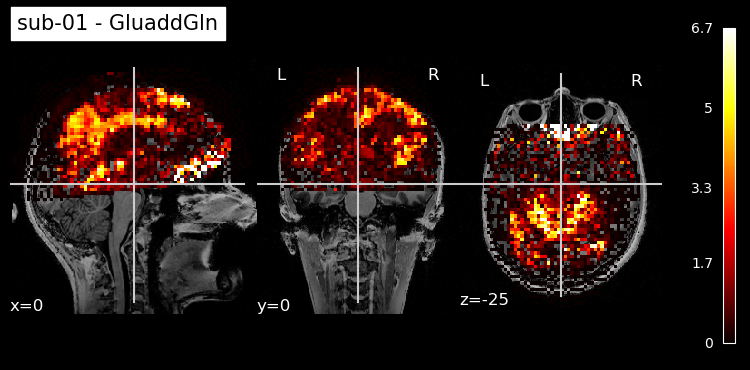

In [41]:
COVERAGE_MAPS = [
    f"{SUBJ}_{SES}_acq-OrigRes_desc-NAA_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Cr_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Glu_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Ins_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-GABA_mrsi.nii.gz",
    f"{SUBJ}_{SES}_acq-OrigRes_desc-GluaddGln_mrsi.nii.gz",
]
plot_coverage_grid(COVERAGE_MAPS, MRS_DIR, T1W_PATH, subj=SUBJ)


## 5 – Support mask: pure binary spatial footprint

Binary mask of where signal exists, overlaid on the T1w.


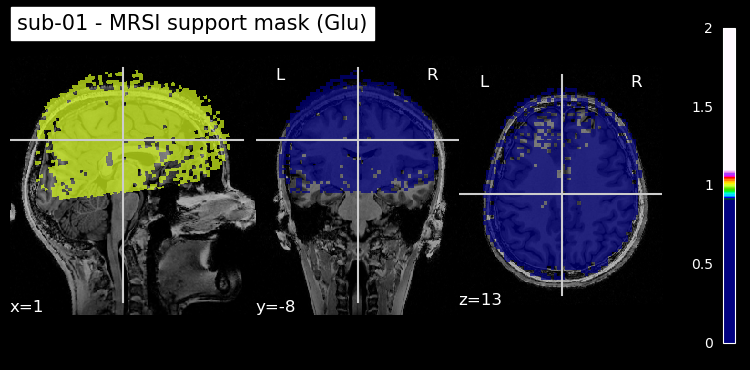

  Brain coverage: 14.1%


0.1414142215021152

In [42]:
plot_support_mask(
    f"{SUBJ}_{SES}_acq-OrigRes_desc-Glu_mrsi.nii.gz",
    T1W_PATH, MRS_DIR, subj=SUBJ,
)

## 7 – Sum of all metabolite maps (native MRS space)


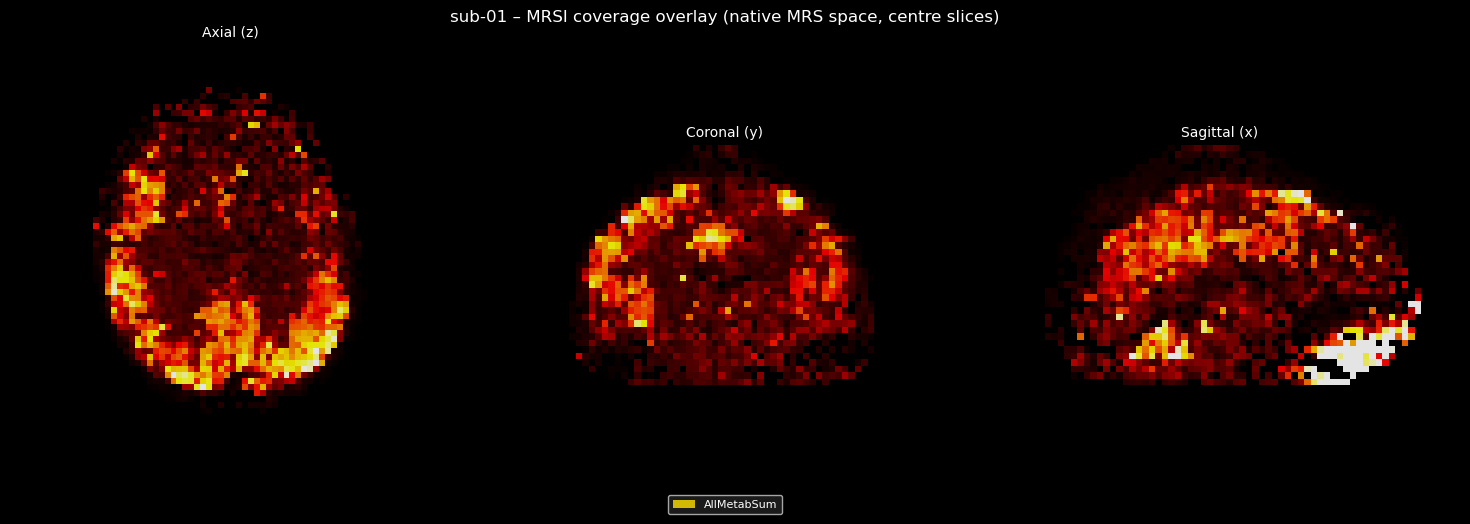

In [43]:

# visualise all 3 orthogonal centre slices side by side
plot_mrsi_combined([SUM_NAME], MRS_DIR, subj=SUBJ, cmaps=["hot"], alpha=0.9)


## 8 – Downsampled T1w at MRSI resolution

The T1w UNI-DEN image is resampled to the exact voxel grid of the MRSI concentration maps.

=== Downsampled T1w ===
T1w @ MRS res  (sub-01_ses-01_acq-MRSIres_T1w.nii.gz)
  shape      : (74, 74, 37)
  voxel size : [2.973 2.973 2.973] mm
  dtype      : float32

MRS ref        (sub-01_ses-01_acq-OrigRes_desc-2HG_mrsi.nii.gz)
  shape      : (74, 74, 37)
  voxel size : [2.973 2.973 2.973] mm
  dtype      : float32



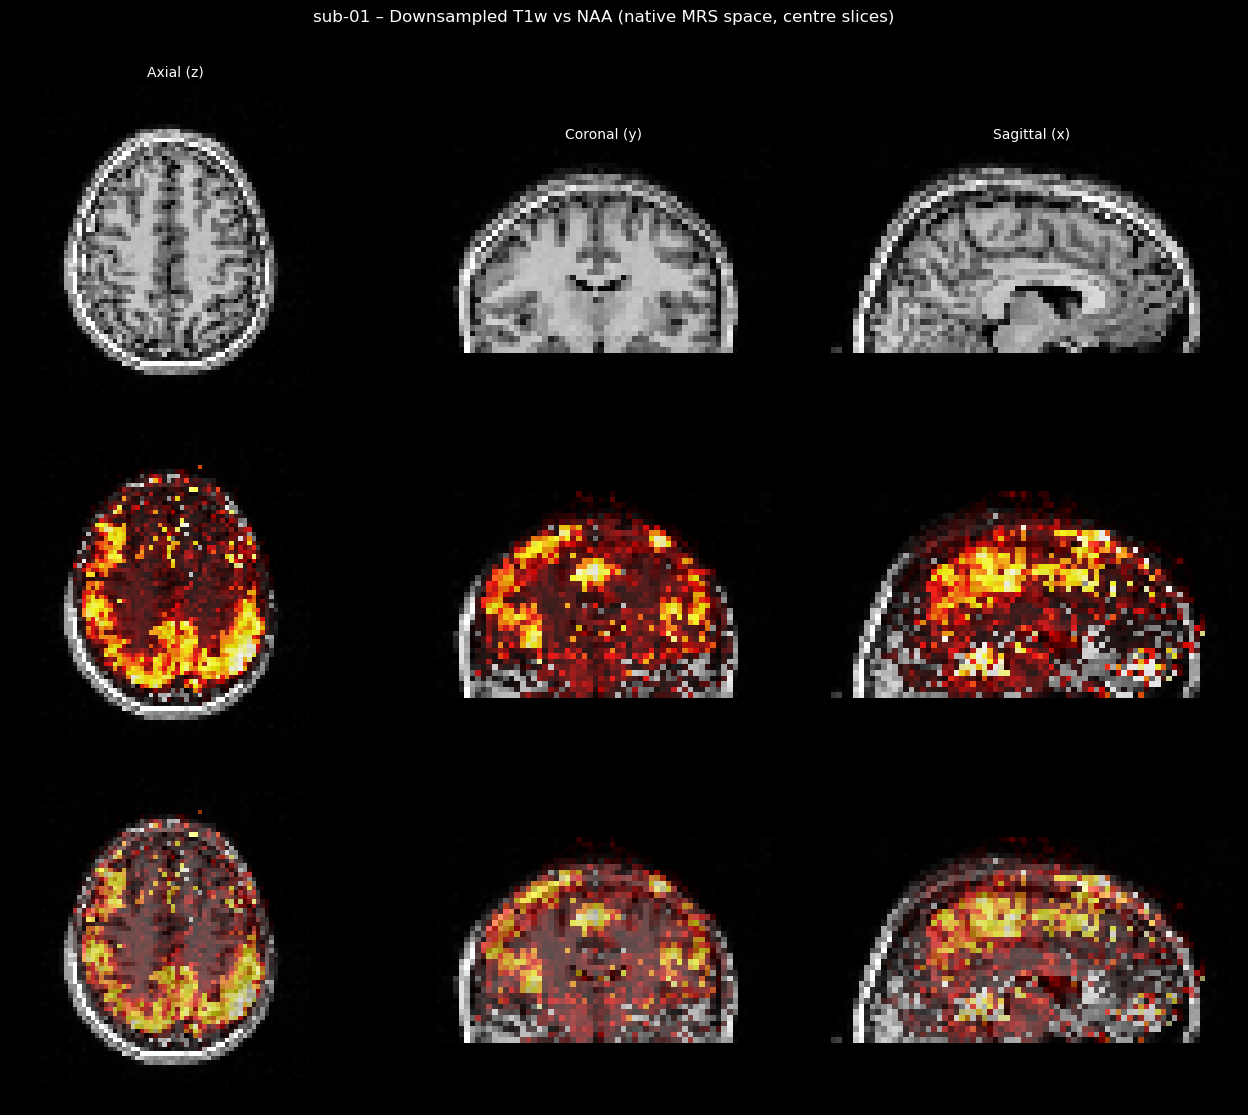

In [46]:
from main import T1W_DS_NAME
print("=== Downsampled T1w ===")
img_info(t1w_ds_img, f"T1w @ MRS res  ({T1W_DS_NAME})")
img_info(mrs_example, f"MRS ref        ({mrs_files[0]})")

# pick NAA as the representative metabolite for the overlay comparison
_ref_metab = f"{SUBJ}_{SES}_acq-OrigRes_desc-NAA_mrsi.nii.gz"
import nibabel as nib, os
_mrs_img = nib.load(os.path.join(MRS_DIR, _ref_metab))

plot_t1w_mrs_comparison(
    t1w_ds_img,
    _mrs_img,
    subj=SUBJ,
    mrs_label="NAA",
    )


## 9 – Best-SNR metabolite map

All `acq-OrigRes` concentration maps are ranked by their mean VoxelSNR  the scanner derived per voxel SNR map (`desc-VoxelSNR_mrsi`) averaged over the support mask of each metabolite.


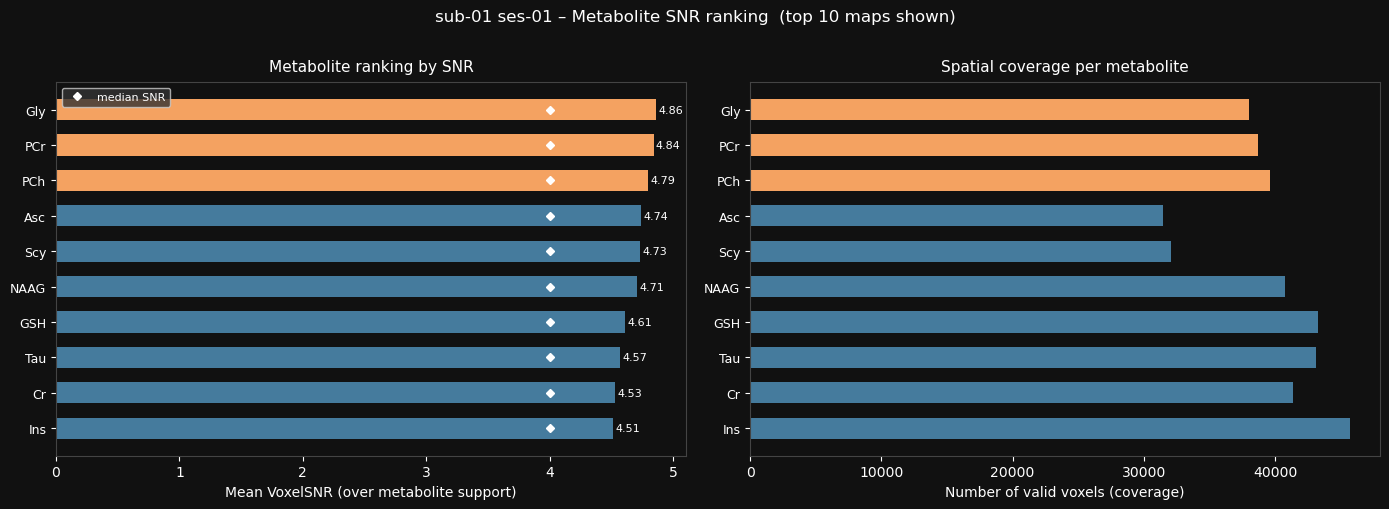


Top-3 metabolites by mean VoxelSNR:
  # 1  Gly                        mean_SNR=4.86  median_SNR=4.00  n_voxels=38,015  CV=9.187
  # 2  PCr                        mean_SNR=4.84  median_SNR=4.00  n_voxels=38,708  CV=4.719
  # 3  PCh                        mean_SNR=4.79  median_SNR=4.00  n_voxels=39,631  CV=2.344


In [47]:
# rank all metabolites by SNR using the scanner-provided VoxelSNR map
snr_records = rank_metabolites_by_snr(MRS_DIR, subj=SUBJ, ses=SES)

# bar chart: mean/median SNR + coverage for the top-20 maps
plot_snr_ranking(snr_records, top_n=10, highlight_best=3)


Best SNR metabolite: Gly  (mean_SNR=4.86)


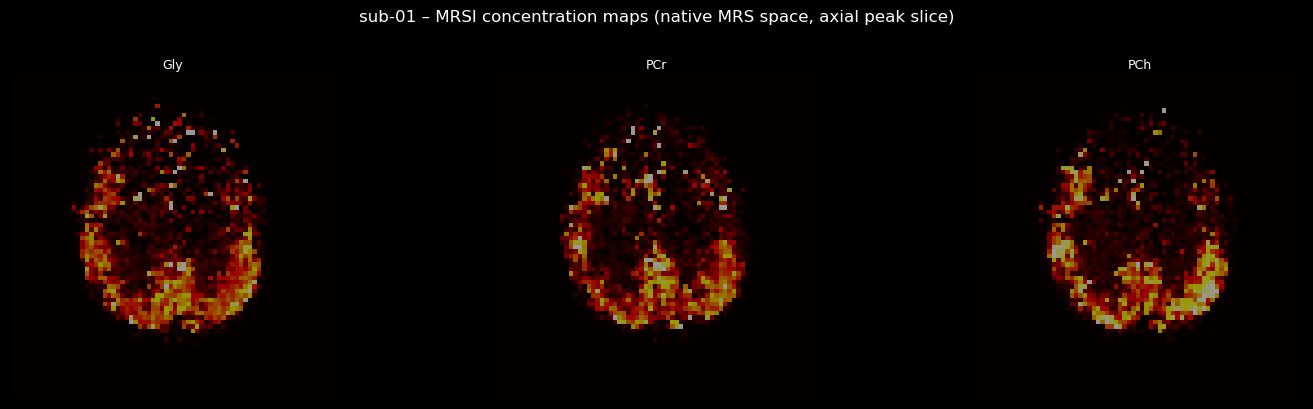

In [49]:
# visualise the best-SNR map and the top-3 together
best = snr_records[0]
top3 = [r["filename"] for r in snr_records[:3]]

print(f"Best SNR metabolite: {best['metabolite']}  (mean_SNR={best['mean_snr']:.2f})")

# mosaic: peak axial slice for each of the top-3 maps
plot_mrsi_mosaic(top3, MRS_DIR, subj=SUBJ, cmap="hot", cols=3)


## 10 – Water mask: raw vs hole-filled comparison



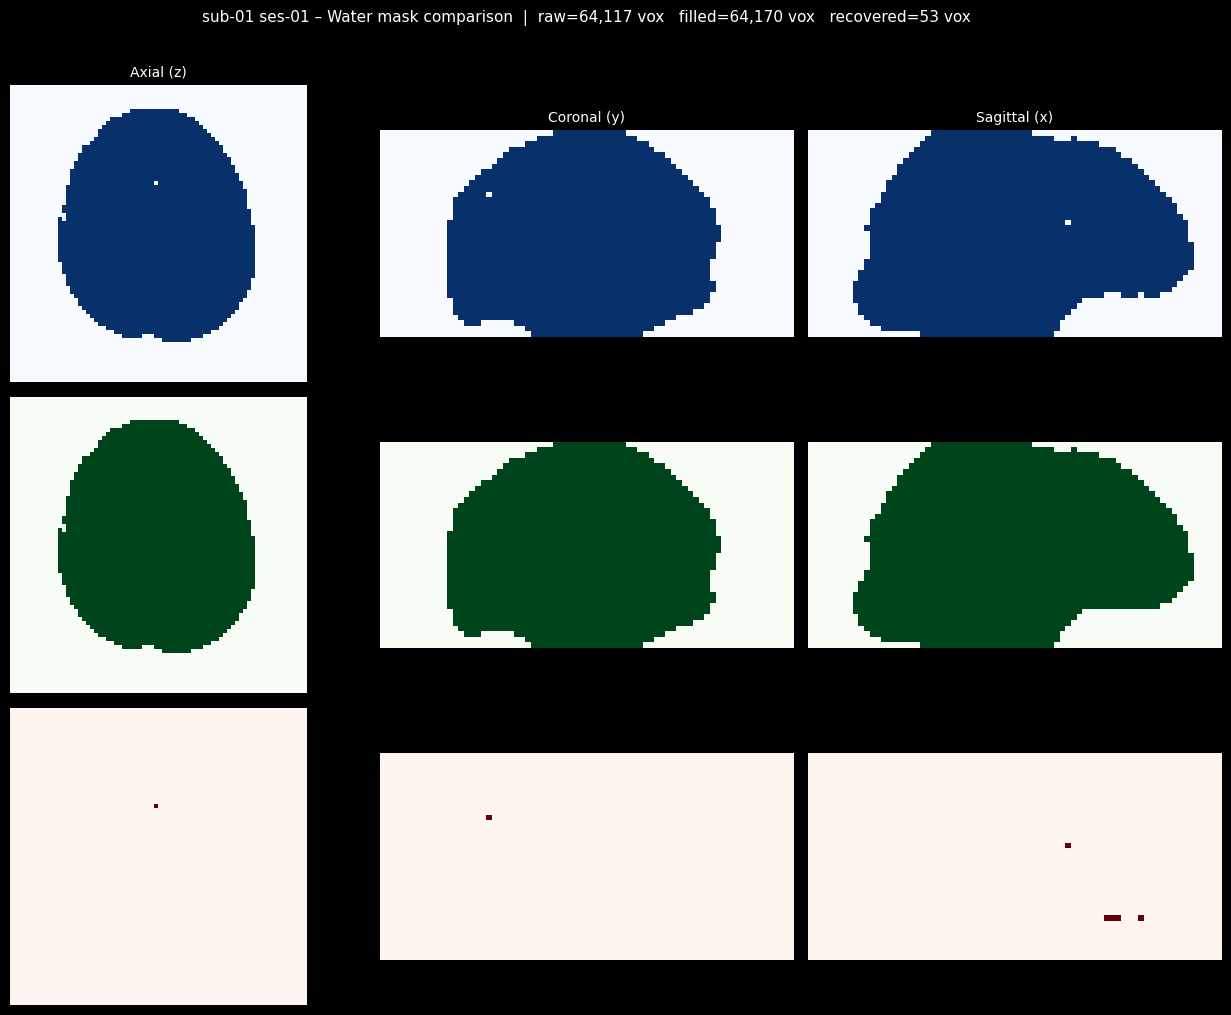

Raw mask voxels   : 64,117
Filled mask voxels: 64,170
Holes recovered   : 53  (0.08% of filled mask)


In [51]:
from main import water_img, water_mask
plot_water_mask_comparison(water_img, water_mask, subj=SUBJ, ses=SES)


## 11 – T1w/MRSI registration: before vs after

The downsampled T1w is masked with the filled water mask and then rigidly registered to the best-SNR MRSI map using ANTsPy. Because both images come from the same subject and session, a rigid transform is used.


Best-SNR metabolite used as registration target: Gly


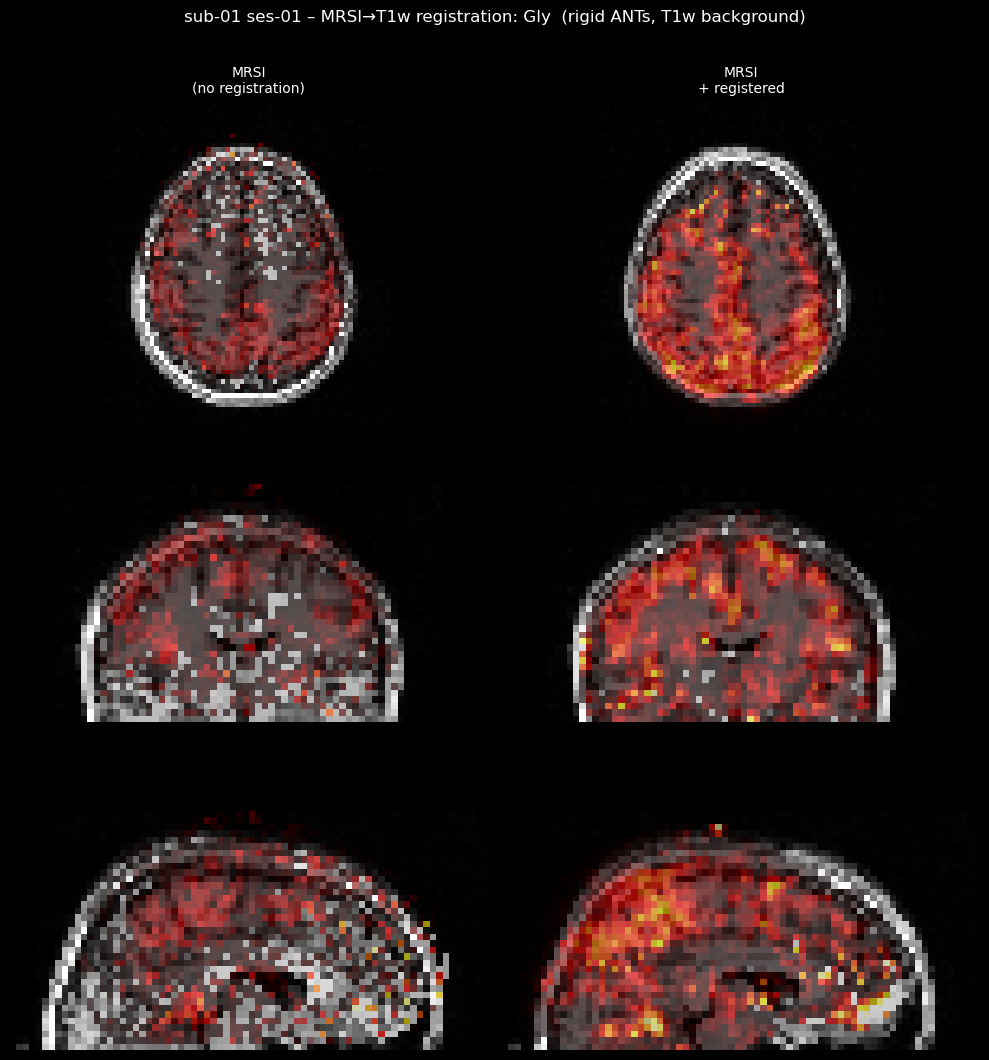

In [55]:
from main import best_mrsi_label, best_mrsi_img, mrsi_reg_ds_img
print(f"Best-SNR metabolite used as registration target: {best_mrsi_label}")
plot_registration_comparison(
    t1w_ds_img,
    best_mrsi_img,
    mrsi_reg_ds_img,
    subj=SUBJ,
    ses=SES,
    mrsi_label=best_mrsi_label,
)


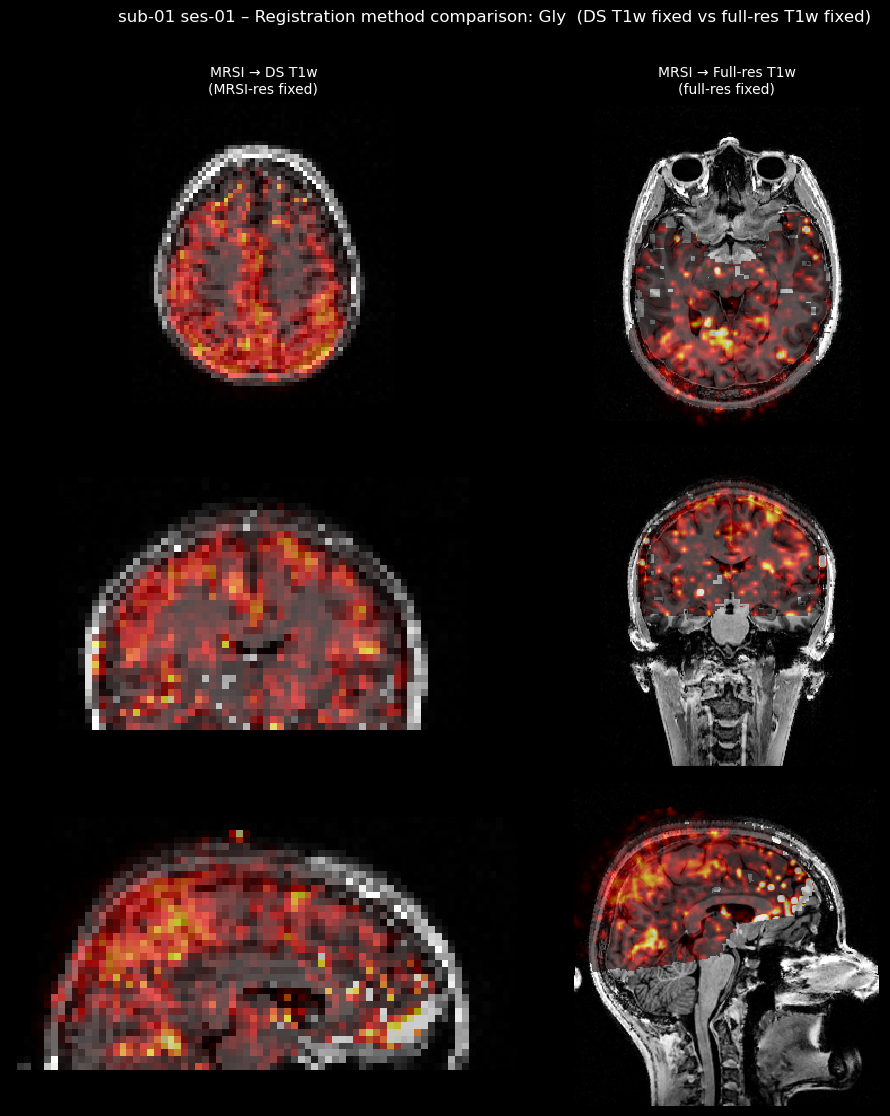

In [57]:
from main import mrsi_reg_fullres_img
plot_registration_methods_comparison(
    t1w_ds_img,
    t1w_img,
    mrsi_reg_ds_img,
    mrsi_reg_fullres_img,
    subj=SUBJ,
    ses=SES,
    mrsi_label=best_mrsi_label,
)


## 12 – Registration target comparison: best-SNR metabolite vs metabolite sum

Two strategies for choosing the moving image to register to the downsampled T1w (rigid ANTs):

- Left  image = best-SNR metabolite map  
- Right image = voxel-wise sum of all metabolite maps



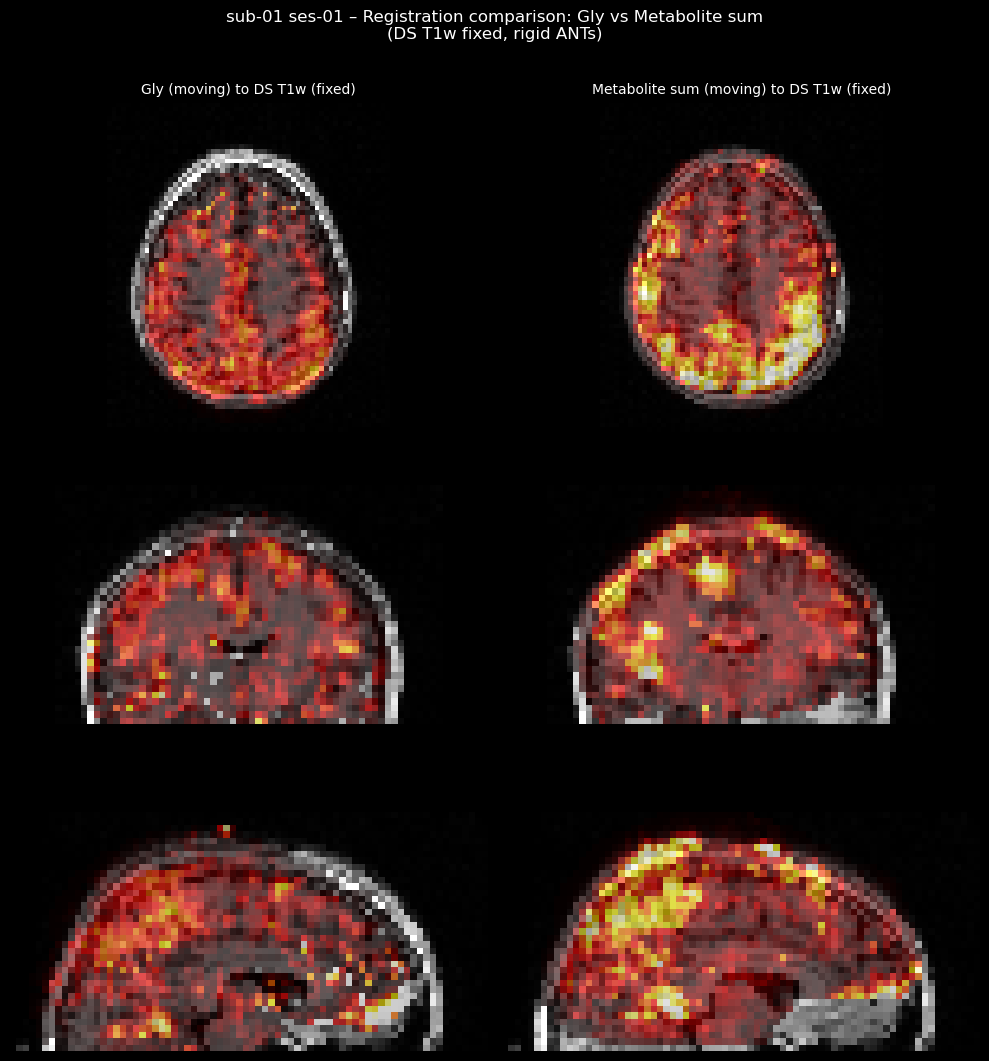

In [59]:
from main import mrsi_sum_reg_img
plot_registration_target_comparison(
    t1w_ds_img,
    mrsi_reg_ds_img,
    mrsi_sum_reg_img,
    subj=SUBJ,
    ses=SES,
    bestsnr_label=best_mrsi_label,
)


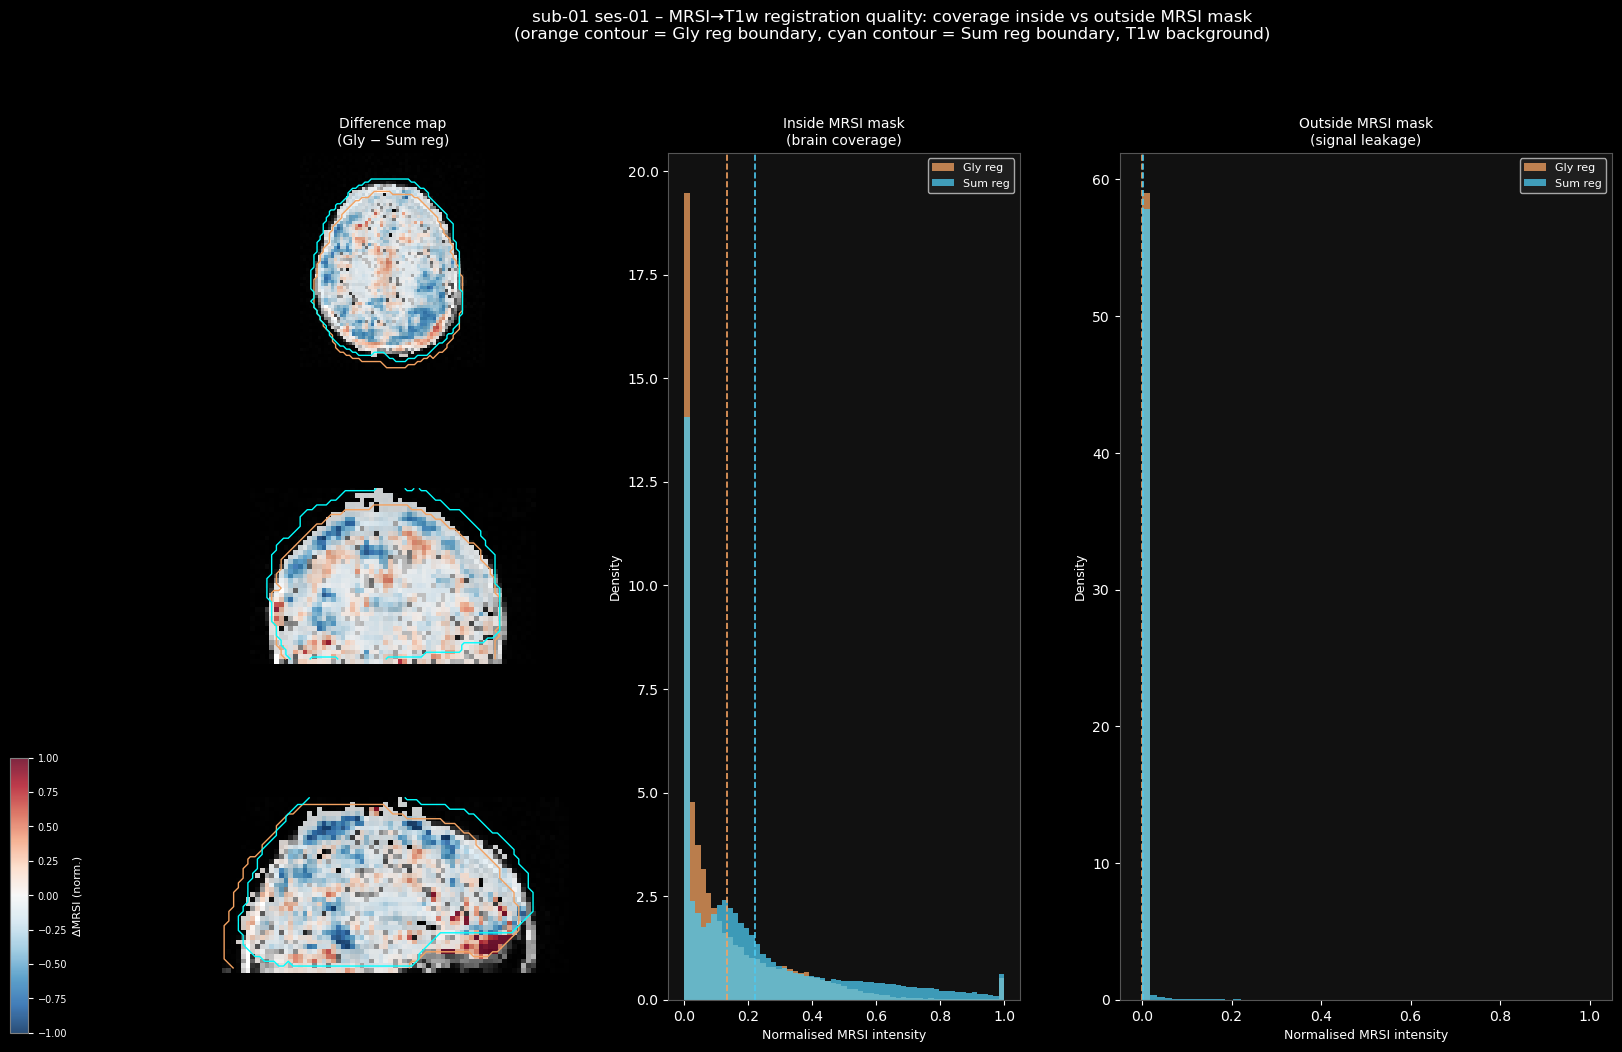

Metric                               Gly reg         Sum reg         Δ (a−b)
────────────────────────────────────────────────────────────────────────────
Mean MRSI in-mask                     0.1335          0.2210         -0.0876
Mean MRSI out-of-mask                 0.0000          0.0021         -0.0021
In/Out SNR ratio              133472412.8246        103.5895  +133472309.2351
% active voxels in-mask              52.8678         68.7056        -15.8378
% active voxels out                   0.0000          1.0017         -1.0017


In [64]:
from main import reg1_transforms, reg3_transforms
cov_metrics = compare_registration_coverage(
    t1w_ds_img,
    water_mask,
    best_mrsi_img,
    mrsi_reg_ds_img,
    mrsi_sum_reg_img,
    reg1_transforms,
    reg3_transforms,
    subj=SUBJ,
    ses=SES,
    bestsnr_label=best_mrsi_label,
)


## 13 – Metabolite sum: independent registration vs best-SNR transform reuse

Two ways to bring the gly map into DS T1w space:
- Left independent registration: the gly image is used as the moving image and ANTs solves a new rigid transform optimised specifically for it.
- Right transform reuse: the rigid transform already solved for the sum image is applied directly to the sum, with no re optimisation.


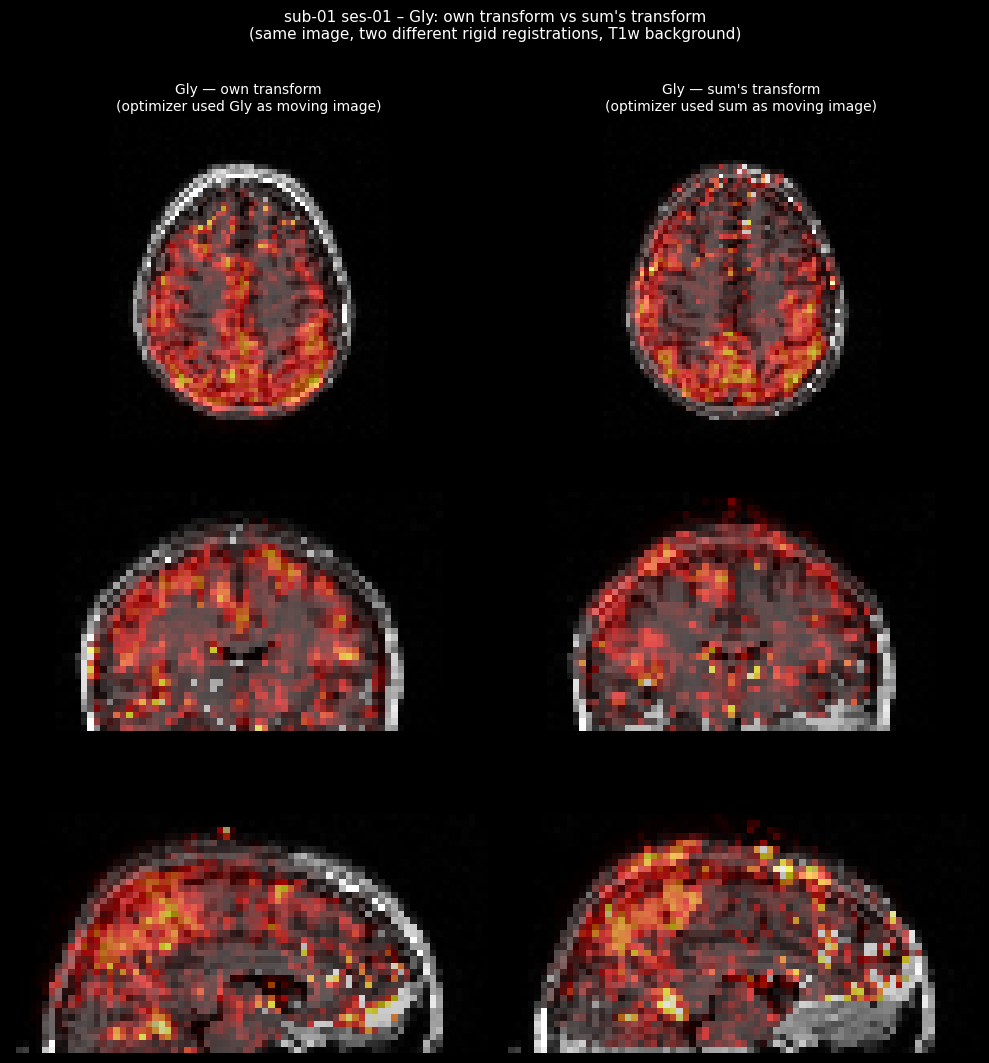

                                   mean in brain   CC with T1w
  ----------------------------------------------------------
  Gly — own transform                     0.1274       -0.0079
  Gly — sum's transform                   0.1356        0.0007


In [67]:
from main import mrsi_gly_via_sum_img
plot_sum_registration_comparison(
    t1w_ds_img,
    mrsi_reg_ds_img,
    mrsi_gly_via_sum_img,
    subj=SUBJ,
    ses=SES,
    bestsnr_label=best_mrsi_label,
)

## 14 – Coverage-based vs SNR-based registration: three-way comparison

Three ways of placing the Gly map (best-SNR metabolite) and the best-coverage metabolite into DS T1w space, all compared side by side:


Best-coverage metabolite : MM14addLip13aaddLip13baddMM12  (49036 voxels)
Best-SNR (Gly)           : Gly  (38015 voxels)


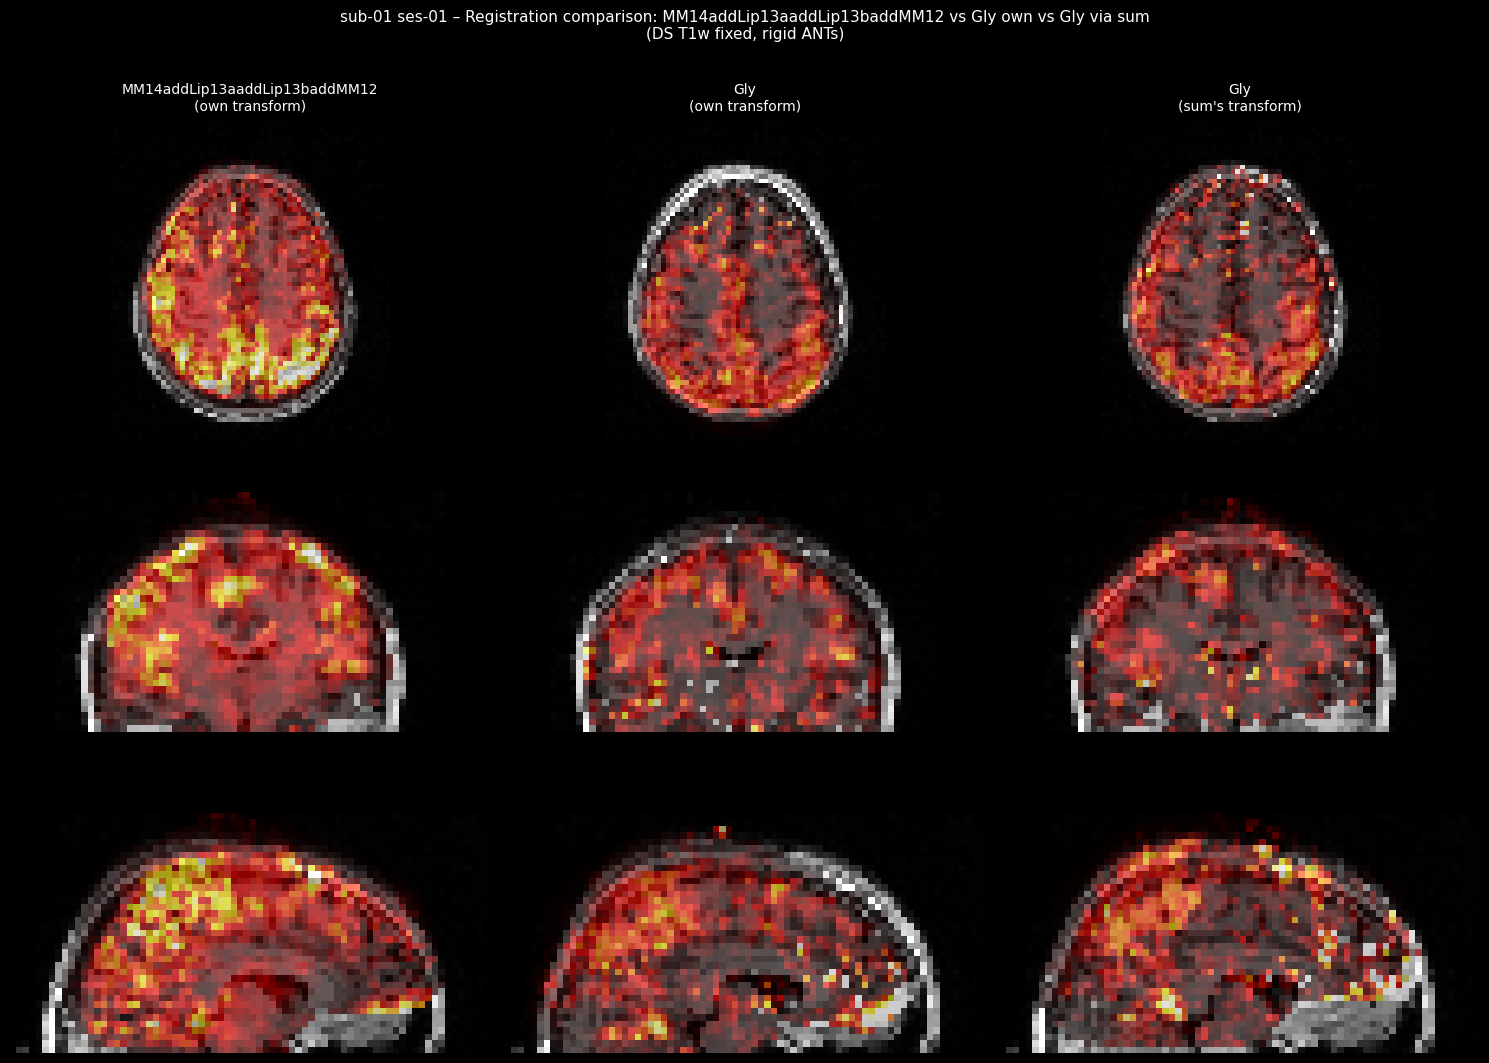


  Strategy                               Mean in brain   CC with T1w
  ------------------------------------------------------------------
  MM14addLip13aaddLip13baddMM12 — own transform          0.2241        0.0438
  Gly — own transform                           0.1274       -0.0079
  Gly — sum's transform                         0.1356        0.0007


In [71]:
from main import best_cov_label,coverage_records,mrsi_cov_reg_img  
print(f"Best-coverage metabolite : {best_cov_label}  ({coverage_records[0]['n_voxels']} voxels)")
print(f"Best-SNR (Gly)           : {best_mrsi_label}  ({snr_records[0]['n_voxels']} voxels)")

plot_coverage_registration_comparison(
    t1w_ds_img,
    mrsi_cov_reg_img,
    mrsi_reg_ds_img,
    mrsi_gly_via_sum_img,
    subj=SUBJ,
    ses=SES,
    cov_label=best_cov_label,
    gly_label=best_mrsi_label,
)


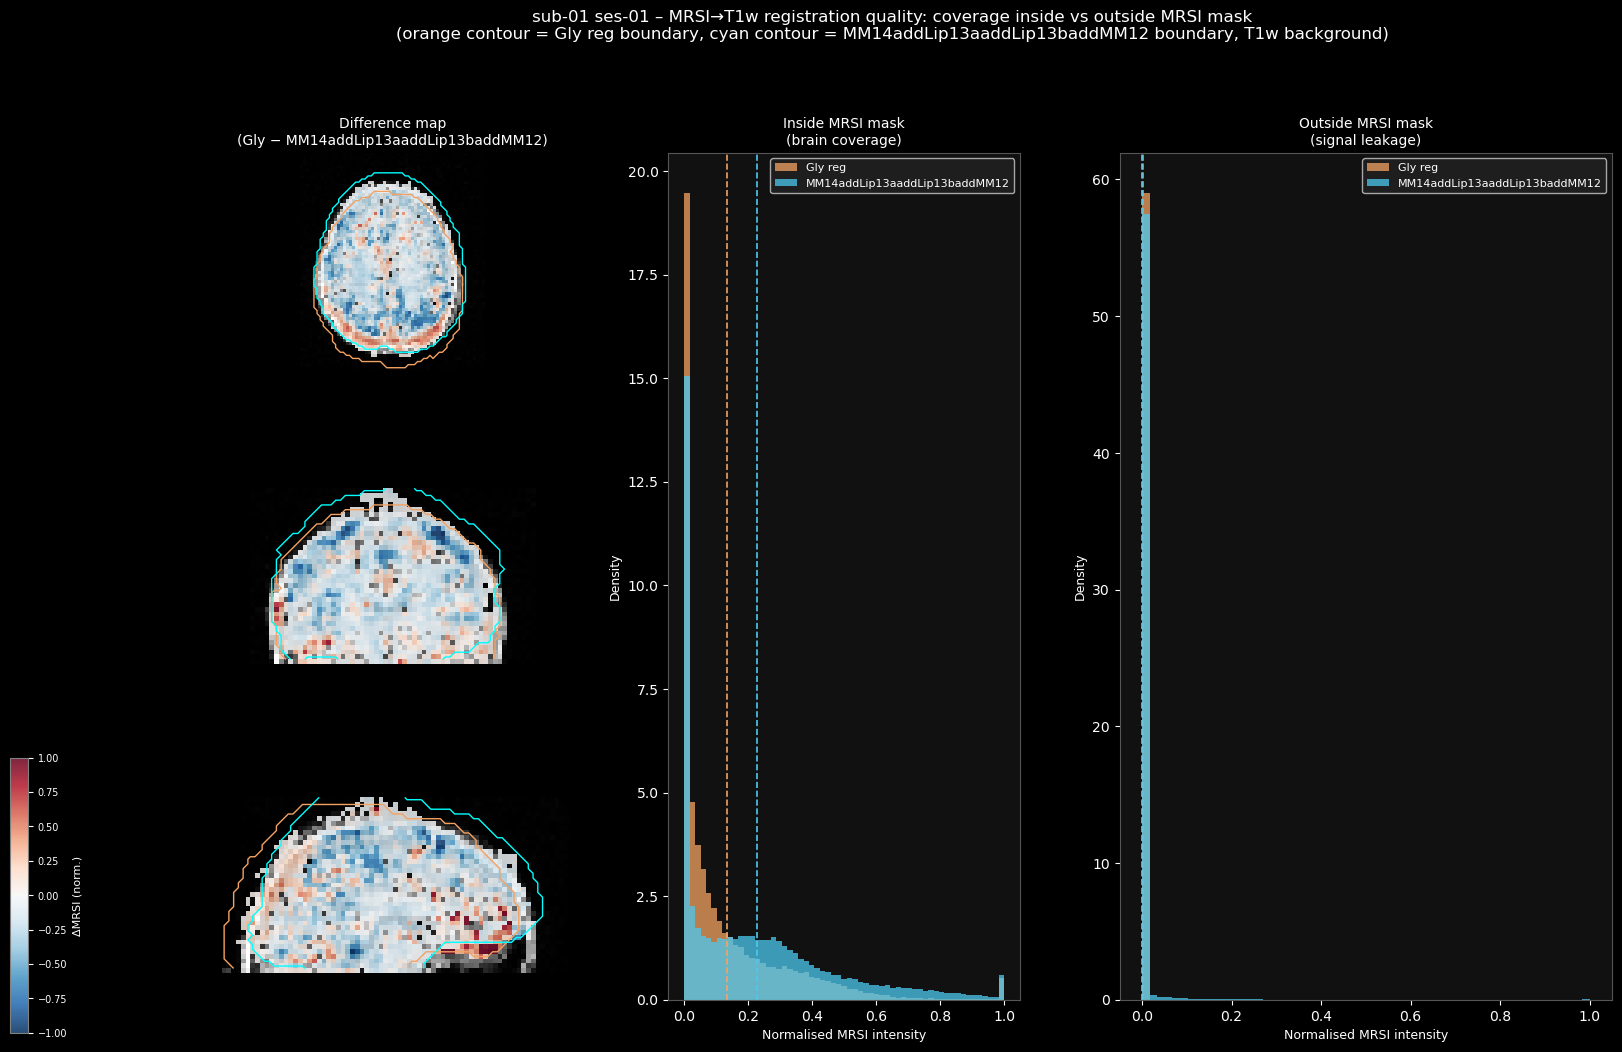

Metric                               Gly reg  MM14addLip13aaddLip13baddMM12         Δ (a−b)
───────────────────────────────────────────────────────────────────────────────────────────
Mean MRSI in-mask                     0.1335          0.2270         -0.0935
Mean MRSI out-of-mask                 0.0000          0.0032         -0.0032
In/Out SNR ratio              133472412.8246         69.9473  +133472342.8773
% active voxels in-mask              52.8678         67.8800        -15.0122
% active voxels out                   0.0000          1.6125         -1.6125


{'best_snr': {'mean_in': 0.13347241282463074,
  'mean_out': 0.0,
  'snr_ratio': 133472412.82463072,
  'pct_active_in': 52.86780210867802,
  'pct_active_out': 0.0},
 'sum': {'mean_in': 0.22697535157203674,
  'mean_out': 0.003244946710765362,
  'snr_ratio': 69.94730633687215,
  'pct_active_in': 67.87996755879968,
  'pct_active_out': 1.612491309714675}}

In [74]:
from main import reg6_transforms
compare_registration_coverage(
    t1w_ds_img,
    water_mask,
    best_mrsi_img,
    mrsi_reg_ds_img,
    mrsi_cov_reg_img,
    reg1_transforms,
    reg6_transforms,
    subj=SUBJ,
    ses=SES,
    bestsnr_label=best_mrsi_label,
    sum_label=best_cov_label,
)


## 15 – Inverse registration: T1w to MRSI space

Register the downsampled T1w (moving) to each MRSI map (fixed).




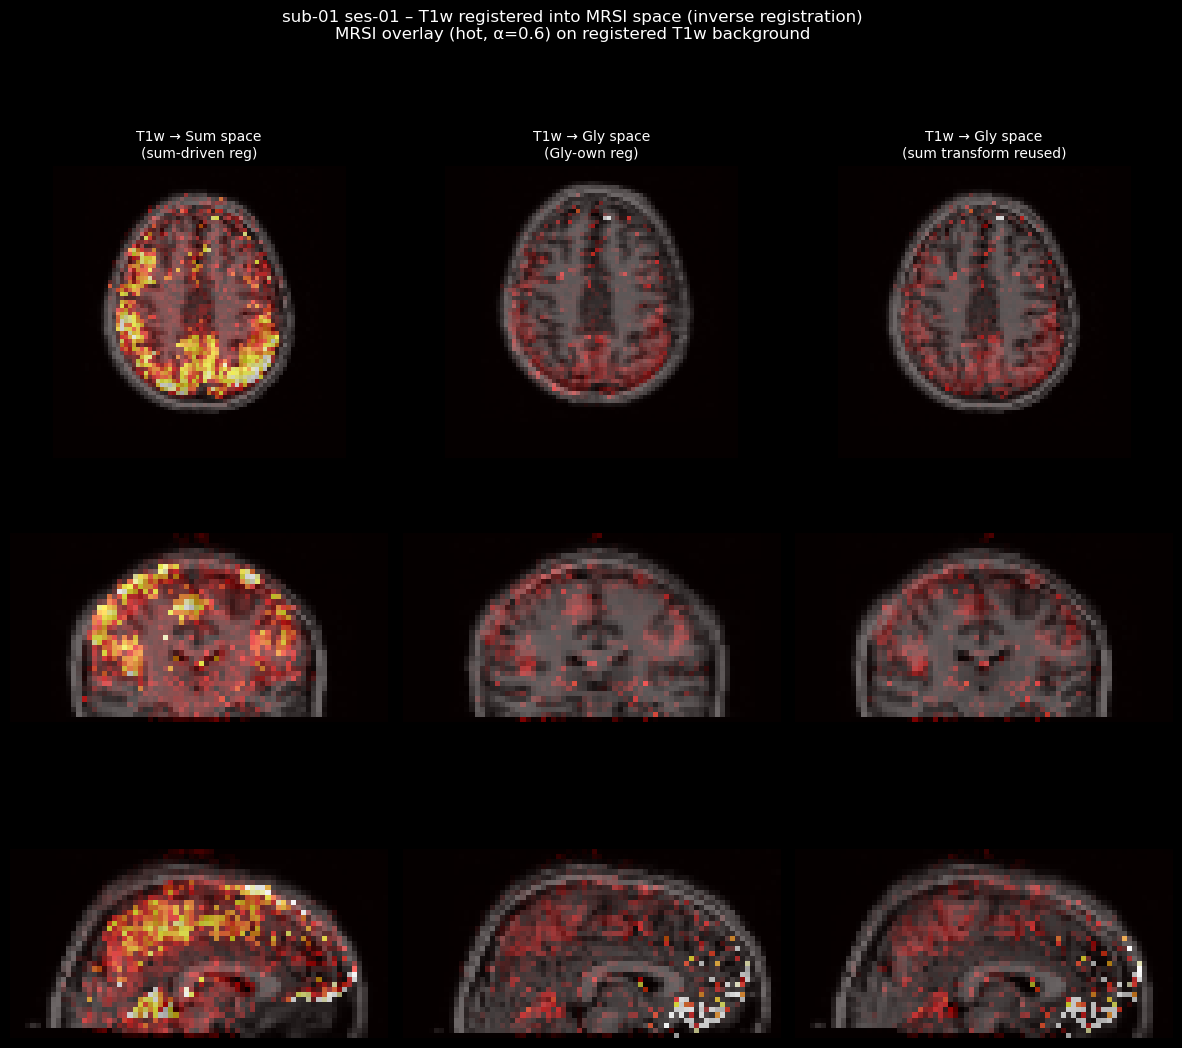

In [79]:
from main import sum_img, t1w_in_sum_img,t1w_in_gly_img, t1w_via_sum_in_gly_img 
plot_inverse_registration_panels(
    mrsi_sum_img=sum_img,
    mrsi_gly_img=best_mrsi_img,
    t1w_via_sum_img=t1w_in_sum_img,
    t1w_via_gly_img=t1w_in_gly_img,
    t1w_via_sum_in_gly_img=t1w_via_sum_in_gly_img,
    subj=SUBJ,
    ses=SES,
    sum_label="Sum",
    gly_label=best_mrsi_label,
)


## 16 – Weighted inverse registration: water signal as mask

Supply the water signal image  as `mask` (fixed-image mask) in ANTs.

Three comparisons on the MRSI background:
- Left  T1w via no weighting mask inverse registration (Reg 8).
- Right  T1w via water weighted inverse registration (Reg 10).

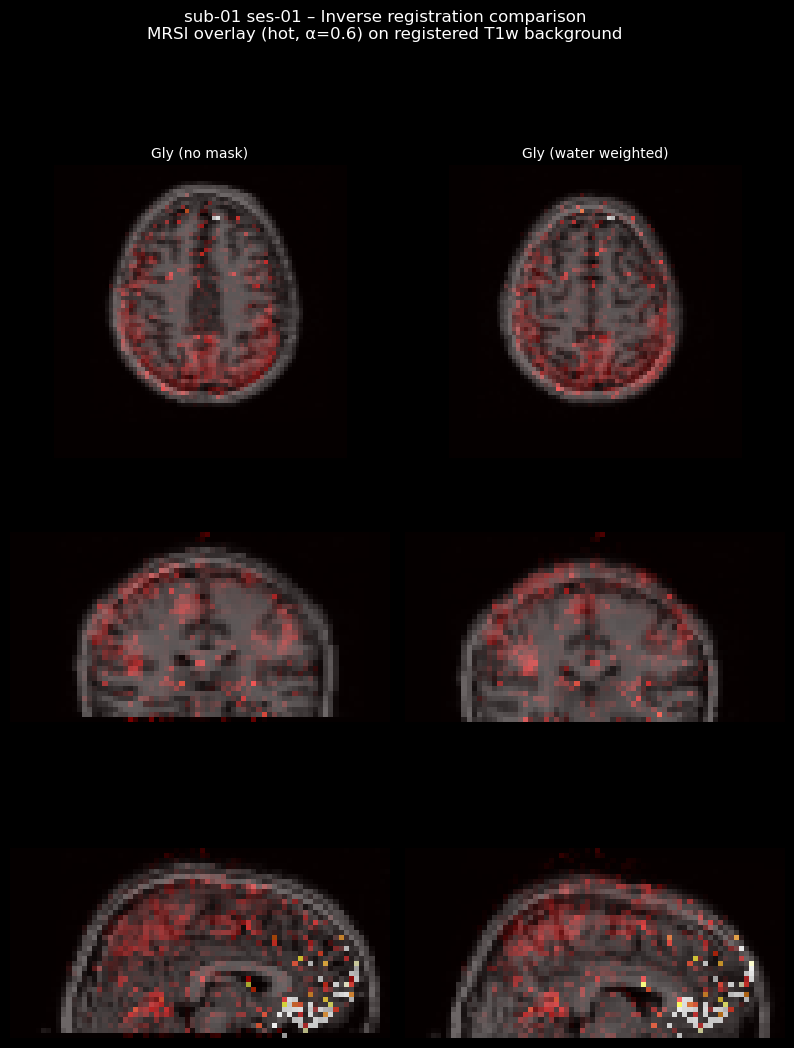

In [83]:
from main import t1w_in_gly_w_img, t1w_in_sum_w_img
compare_inverse_registration_pair(
    best_mrsi_img,
    t1w_in_gly_img,
    t1w_in_gly_w_img,
    subj=SUBJ,
    ses=SES,
    label_left=f"{best_mrsi_label} (no mask)",
    label_right=f"{best_mrsi_label} (water weighted)",
)

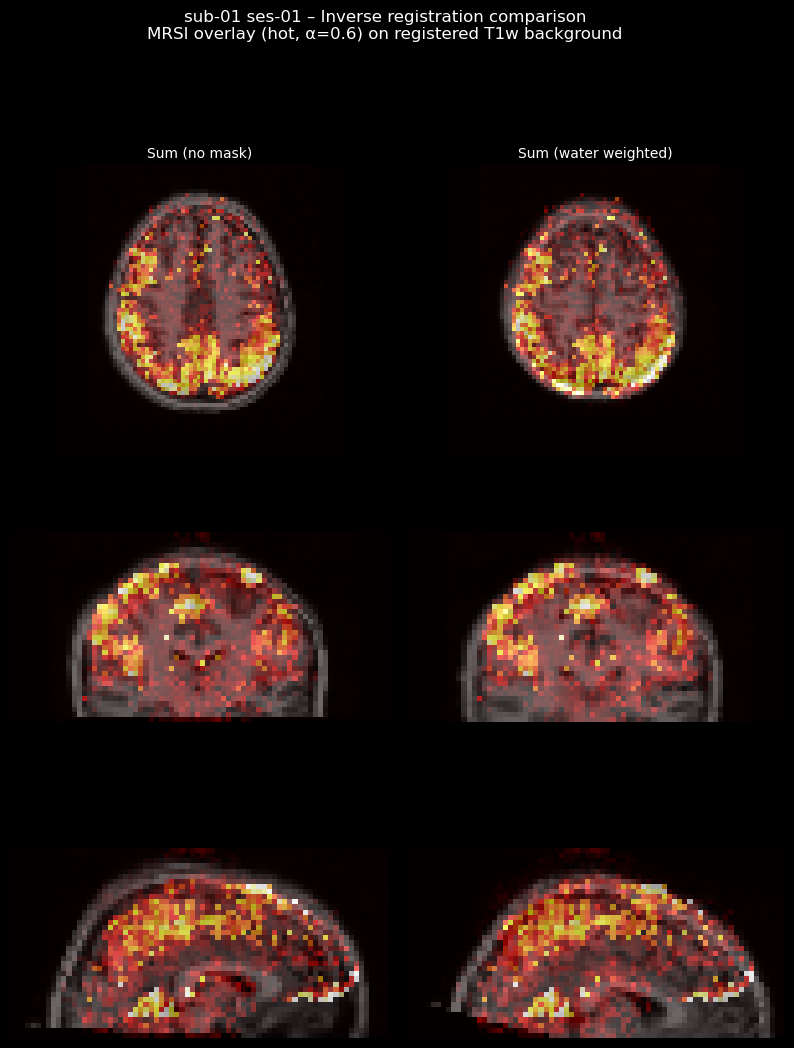

In [84]:
compare_inverse_registration_pair(
    sum_img,
    t1w_in_sum_img,
    t1w_in_sum_w_img,
    subj=SUBJ,
    ses=SES,
    label_left="Sum (no mask)",
    label_right="Sum (water weighted)",
)

## 17 – Water map alignment: naive vs Reg-11 reused vs Reg-18 direct

Three-way comparison on the **water signal map** background (all T1w images in water-signal coordinate space):

| Column | Method | Description |
|--------|--------|-------------|
| Left | Naive | Full-res T1w directly resampled to water grid — no registration |
| Middle | Reg-11 reused | Reg-11 sum water-weighted transform (`inv_sum_w_transforms`) applied to T1w DS, resampled to water space — no re-optimisation |
| Right | Reg-18 | T1w DS directly registered to water signal map (ANTs CLI rigid + water mask) |


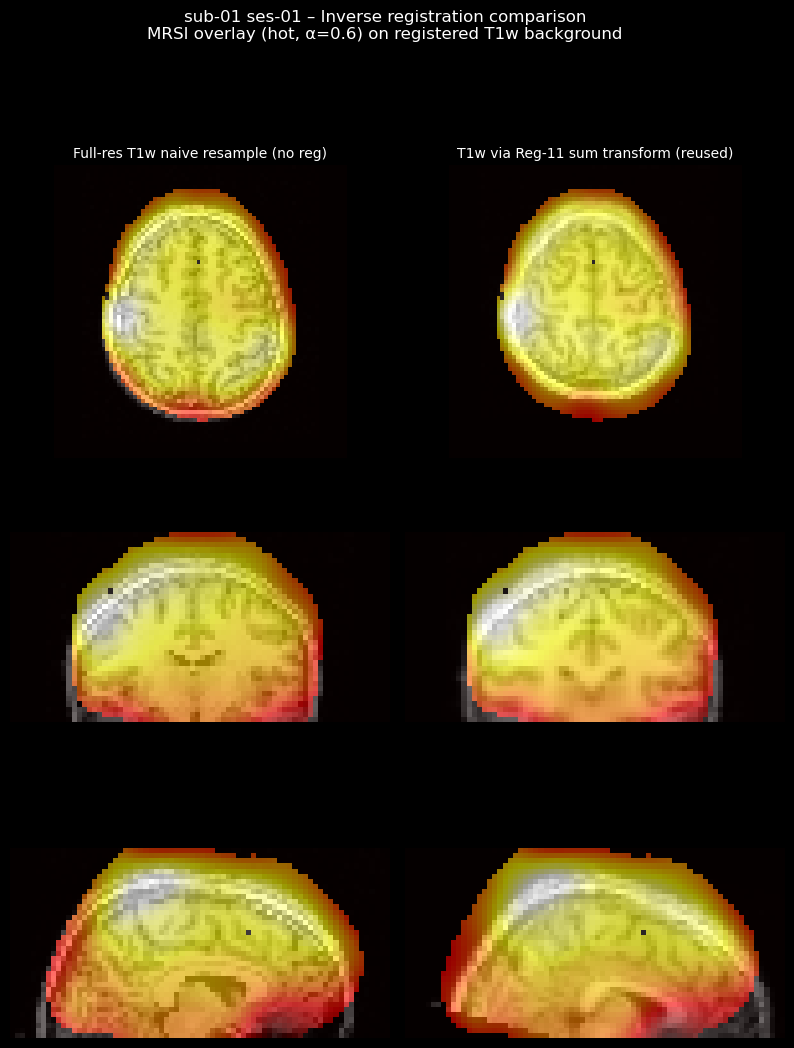

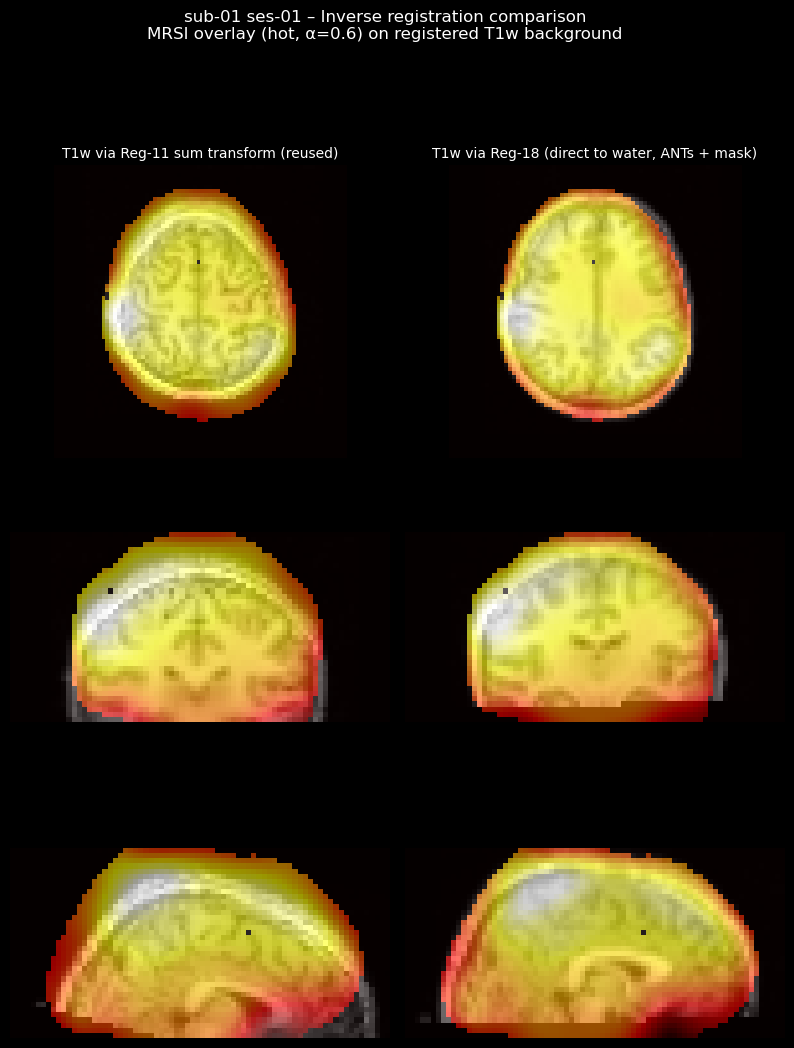

In [87]:
from main import  t1w_in_water_via17_img, t1w_in_water_img
# Left vs middle: naive resample vs Reg-11 sum transform reused
compare_inverse_registration_pair(
    water_img,
    t1w_ds_img,
    t1w_in_water_via17_img,
    subj=SUBJ,
    ses=SES,
    label_left="Full-res T1w naive resample (no reg)",
    label_right="T1w via Reg-11 sum transform (reused)",
)

# Middle vs right: Reg-11 reused vs Reg-18 direct
compare_inverse_registration_pair(
    water_img,
    t1w_in_water_via17_img,
    t1w_in_water_img,
    subj=SUBJ,
    ses=SES,
    label_left="T1w via Reg-11 sum transform (reused)",
    label_right="T1w via Reg-18 (direct to water, ANTs + mask)",
)


## 18 – Skull-stripped T1w registered to MRSI space

The downsampled T1w is first skull-stripped with FSL BET (`-f 0.3`), then
rigidly registered to each MRSI map.  Removing non-brain tissue focuses ANTs'
metric evaluation entirely on brain voxels, which often improves alignment.


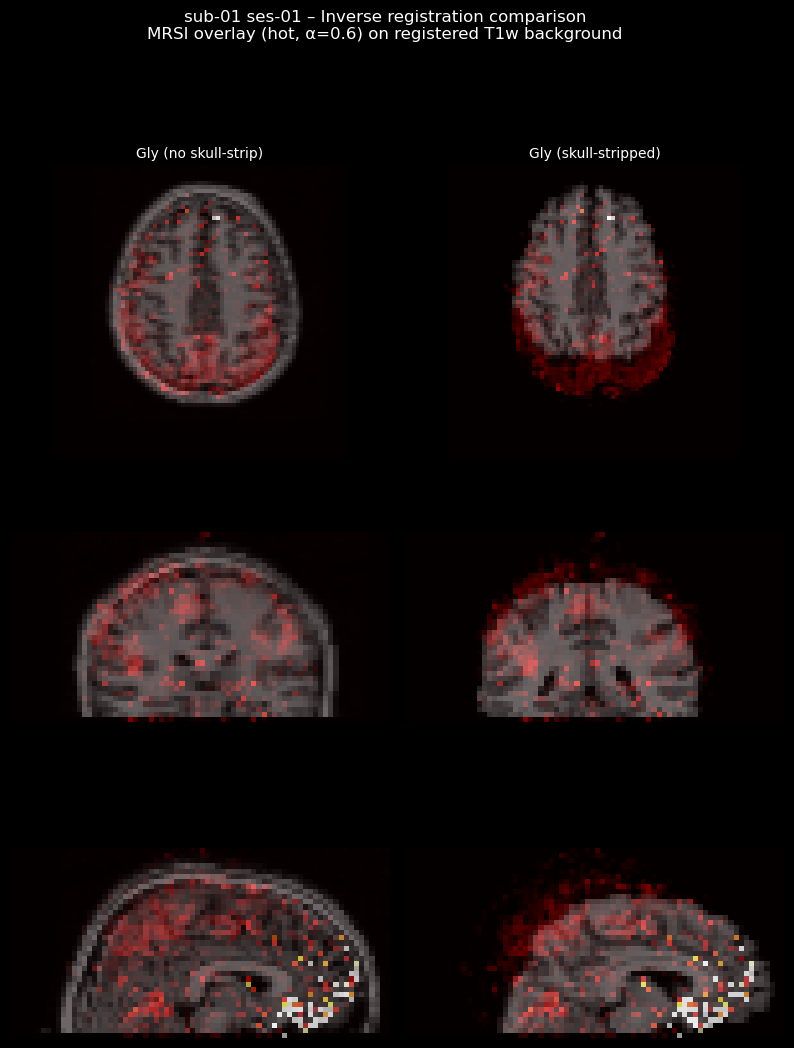

In [91]:
from main import t1w_brain_in_gly_img, t1w_brain_in_sum_img
# Gly: original vs skull-stripped
compare_inverse_registration_pair(
    best_mrsi_img,
    t1w_in_gly_img,
    t1w_brain_in_gly_img,
    subj=SUBJ,
    ses=SES,
    label_left=f"{best_mrsi_label} (no skull-strip)",
    label_right=f"{best_mrsi_label} (skull-stripped)",
)

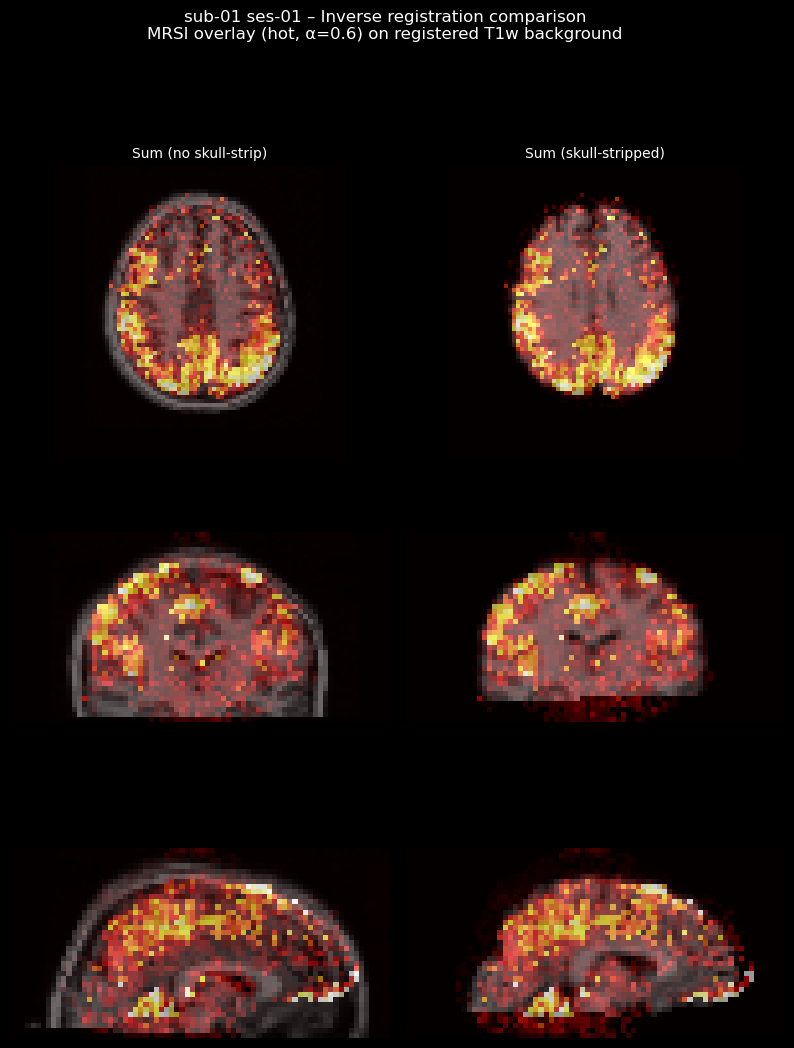

In [92]:
# Sum: original vs skull-stripped
compare_inverse_registration_pair(
    sum_img,
    t1w_in_sum_img,
    t1w_brain_in_sum_img,
    subj=SUBJ,
    ses=SES,
    label_left="Sum (no skull-strip)",
    label_right="Sum (skull-stripped)",
)

## 19 – Total pipeline: reoriented MRSI sum + skull-stripped T1w + water-weighted registration

End-to-end best-practice pipeline combining all preprocessing steps:

1. Reorient all MRSI concentration maps to RAS canonical orientation (`nibabel.as_closest_canonical`).
2. Sum the reoriented maps → `AllMetabSumRAS` (maximises SNR, consistent voxel ordering).
3. Skull-strip the downsampled T1w with FSL BET (`-f 0.3`) to removes non-brain tissue.
4. Register skull-stripped T1w → reoriented sum using `antsRegistration` with the reoriented water signal as a fixed-image weight (`--masks`).

The visualisation below compares:
- Left skull-stripped T1w registered to the *original* (non-reoriented) sum (Reg 15).
- Right  skull-stripped T1w registered to the *reoriented* sum (Reg 17, total pipeline).

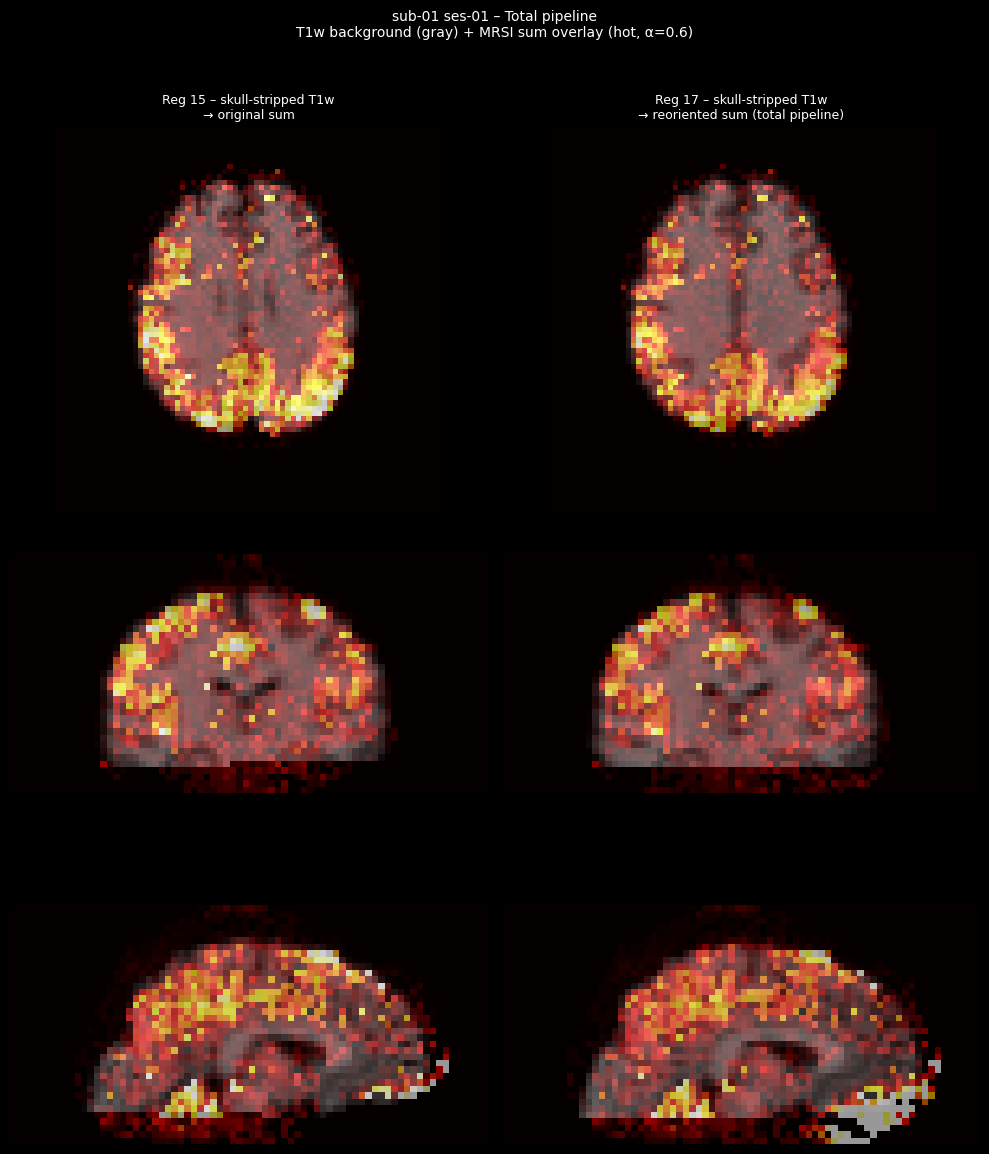

In [95]:
from main import sum_ras_img, t1w_brain_in_sum_ras_img
plot_total_pipeline_comparison(
    sum_orig_img=sum_img,
    t1w_in_sum_orig_img=t1w_brain_in_sum_img,
    sum_ras_img=sum_ras_img,
    t1w_in_sum_ras_img=t1w_brain_in_sum_ras_img,
    subj=SUBJ,
    ses=SES,
)

## 20 – Final transform applied to all metabolites + registration quality metrics

The **Reg-17 transform** (skull-stripped DS T1w → reoriented MRSI sum, water-weighted) is
inverted and applied to every individual metabolite map, warping each one into T1w space
(`antsApplyTransforms [transform.mat, 1]`).

Three quality metrics are computed per metabolite in the **overlap region** (T1w brain > 0 ∩ MRSI signal > 0):

| Metric | Interpretation |
|--------|----------------|
| **Coverage** | Fraction of T1w brain voxels that contain MRSI signal after registration |
| **NCC** | Normalised cross correlation with T1w  higher = better spatial alignment |
| **NMI** | Normalised mutual information  higher = more shared information with T1w |

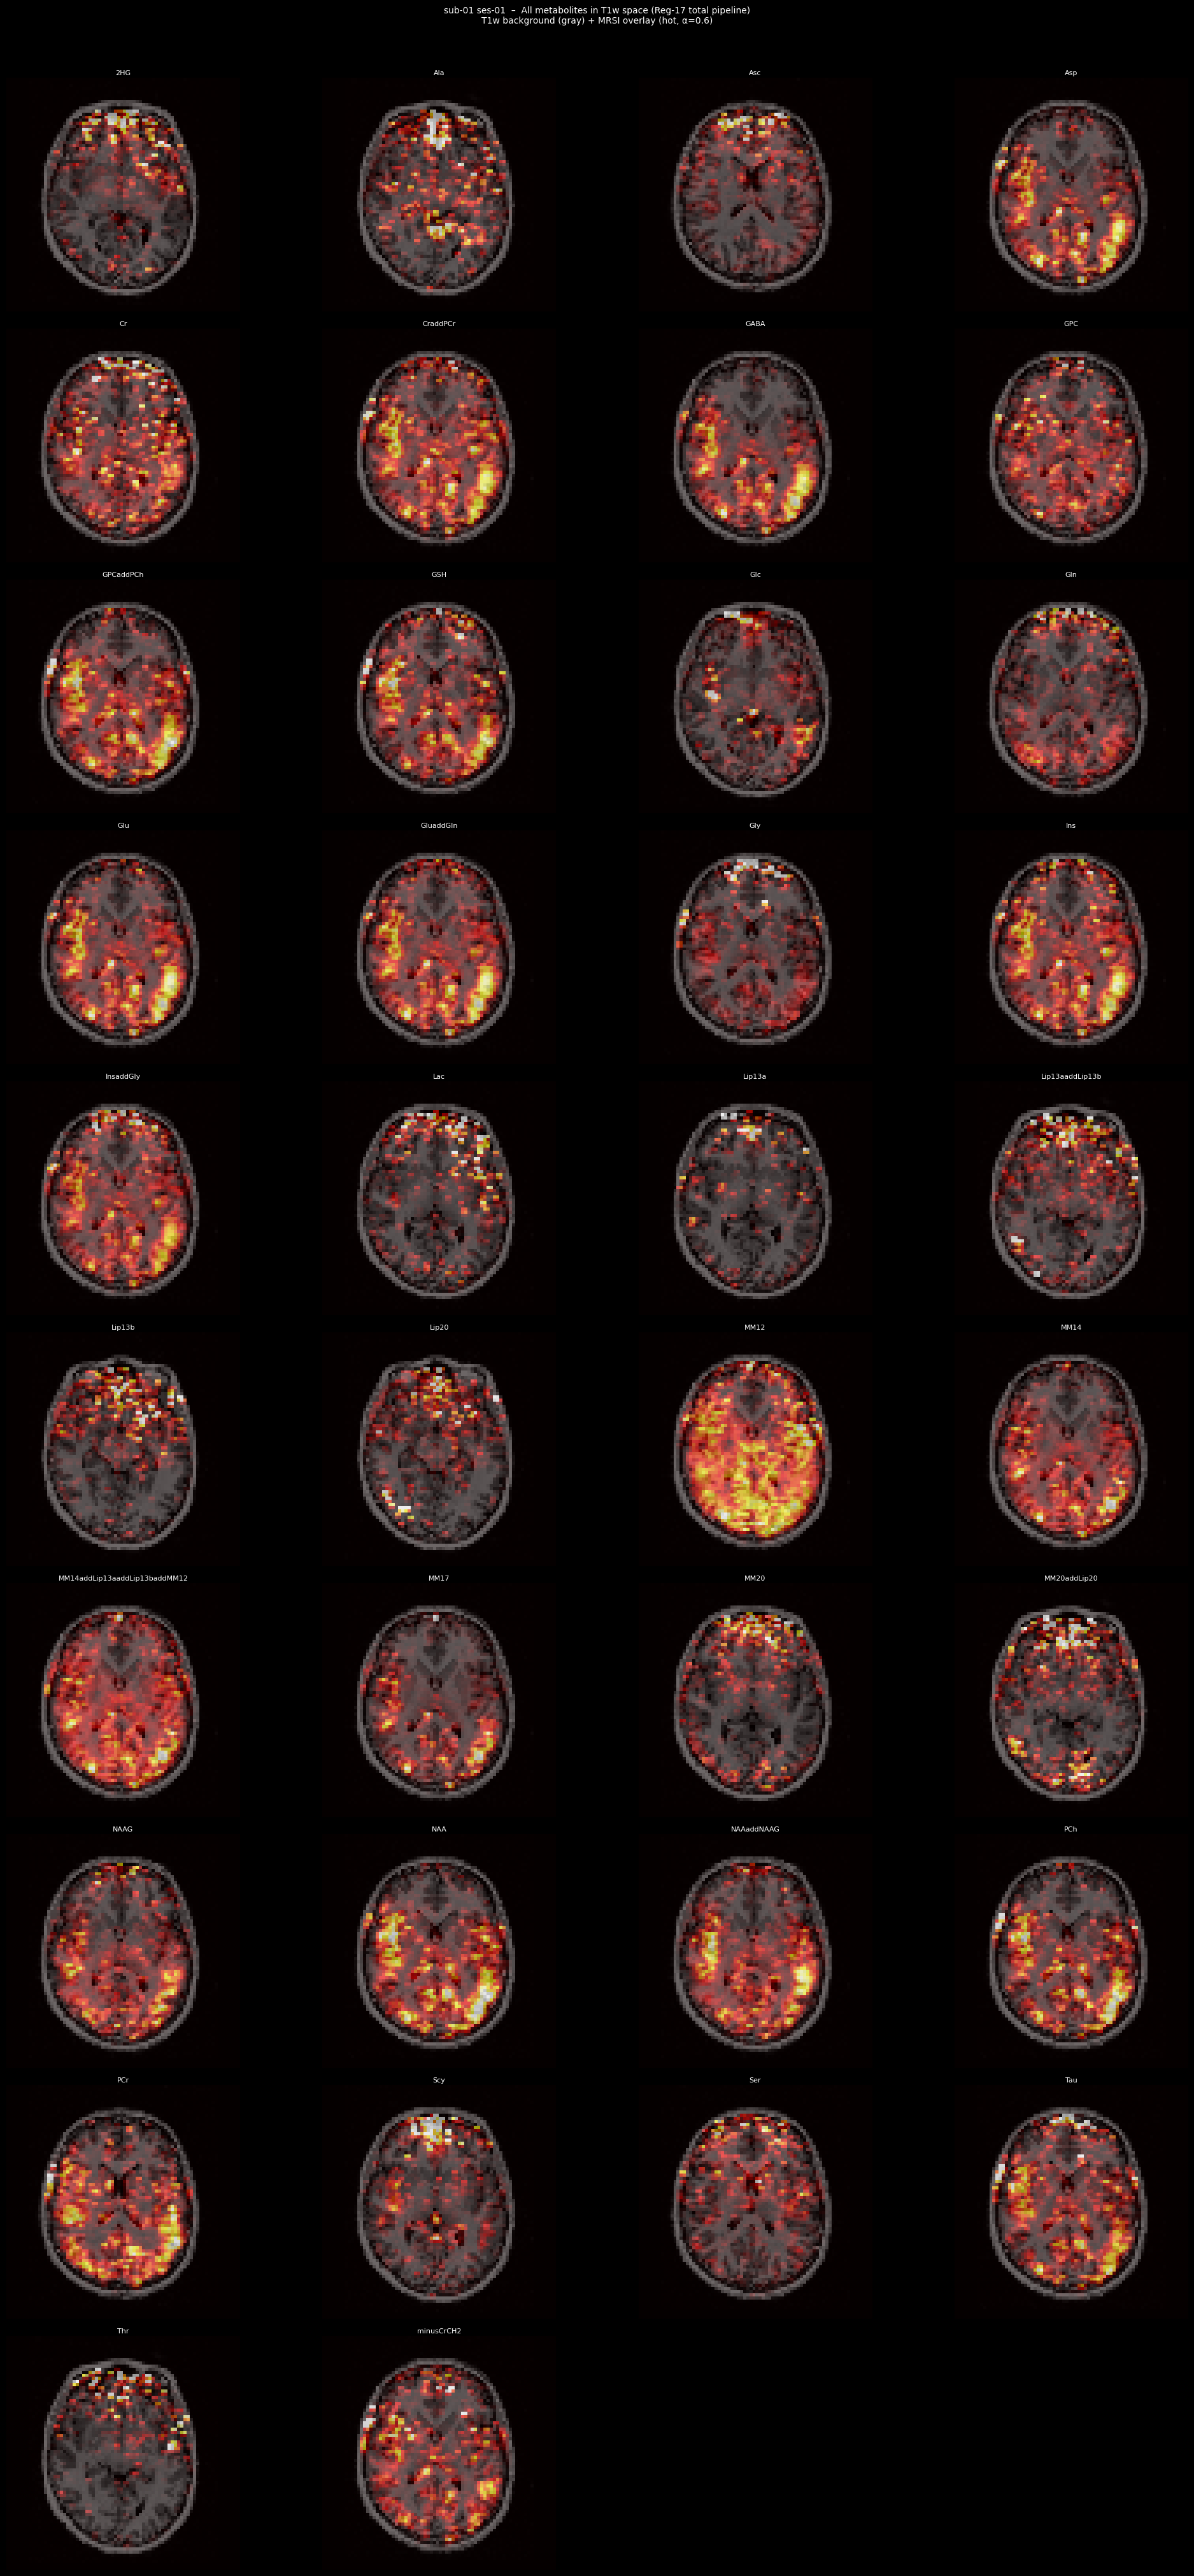

In [97]:
from main import final_reg_imgs
# Axial mosaic: every metabolite overlaid on the T1w background
plot_final_registration_mosaic(
    t1w_img=t1w_ds_img,
    reg_mrsi_imgs=final_reg_imgs,
    subj=SUBJ,
    ses=SES,
)

/Users/user/FCBG_project_Connectome_registraction/Code/FCBG_project_Connectome_registraction/plot_utils.py:1420: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


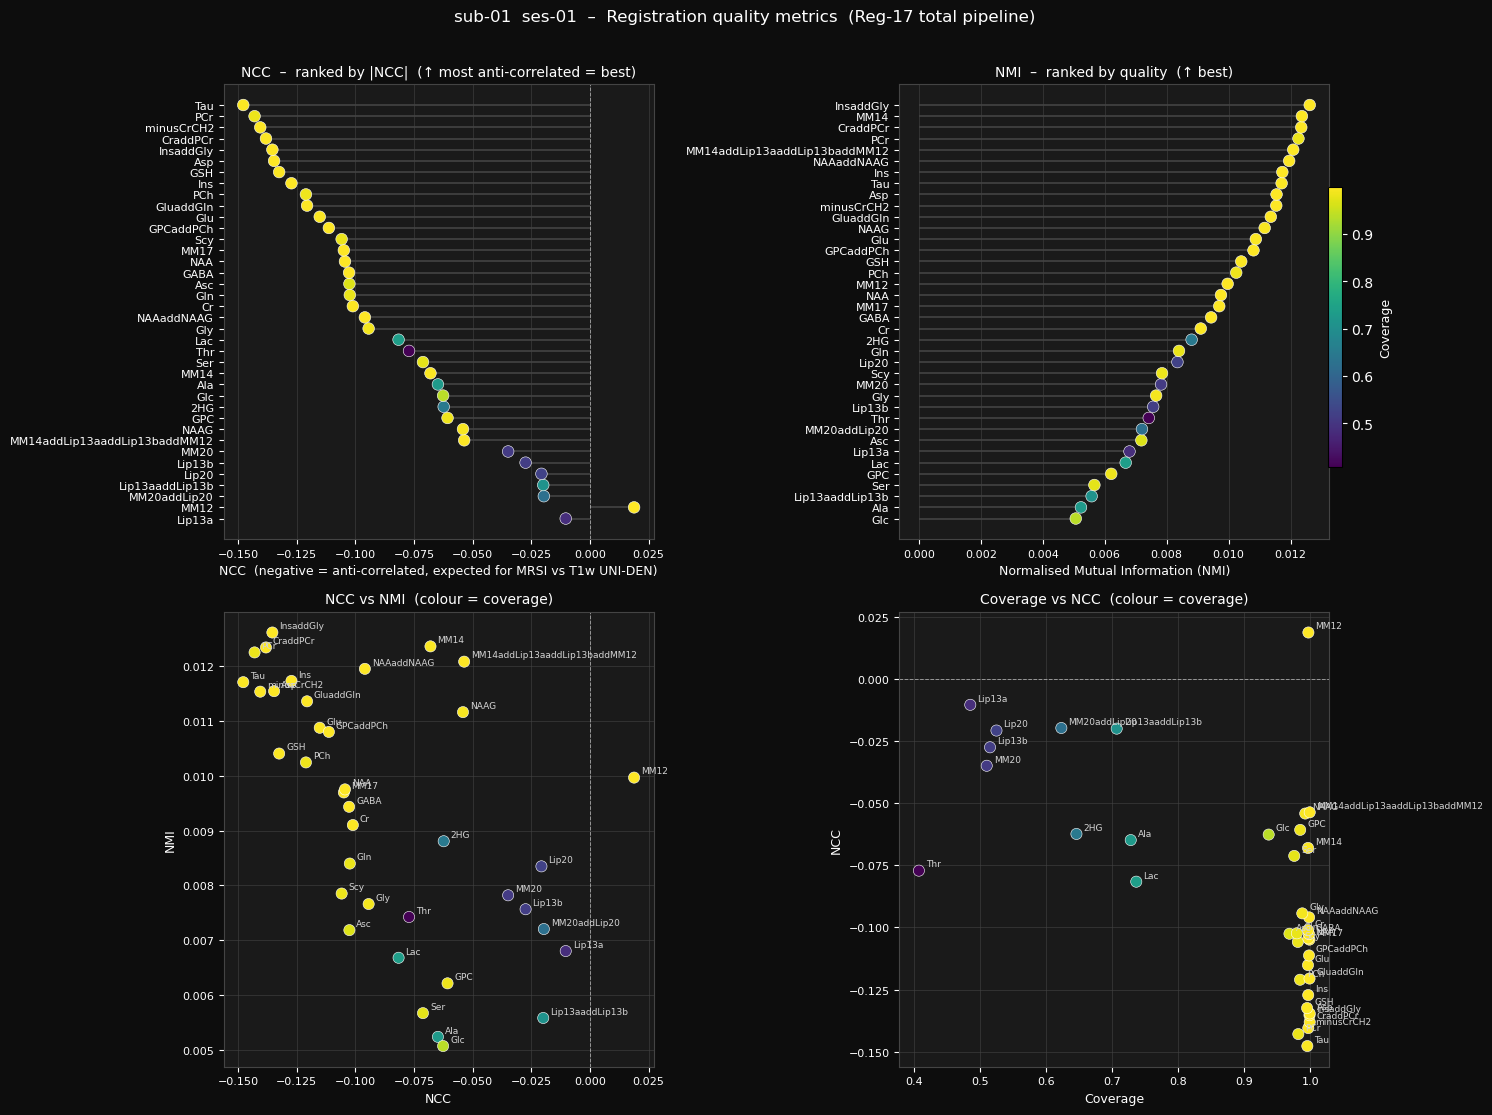


Label                                 Coverage       NCC       NMI
─────────────────────────────────────────────────────────────────
Tau                                      0.996   -0.1478    0.0117
PCr                                      0.982   -0.1429    0.0123
minusCrCH2                               0.997   -0.1405    0.0115
CraddPCr                                 0.999   -0.1381    0.0123
InsaddGly                                0.999   -0.1353    0.0126
Asp                                      0.999   -0.1346    0.0115
GSH                                      0.995   -0.1325    0.0104
Ins                                      0.997   -0.1272    0.0117
PCh                                      0.985   -0.1211    0.0102
GluaddGln                                0.999   -0.1206    0.0114
Glu                                      0.997   -0.1152    0.0109
GPCaddPCh                                0.998   -0.1113    0.0108
Scy                                      0.981   -0.1058    0.

In [99]:
from main import metrics
# Per-metabolite analytical charts: coverage, NCC, NMI
# Recompute if metrics is stale / was overwritten by an earlier cell
if not isinstance(metrics, list) or not metrics:
    if isinstance(final_reg_imgs, dict) and final_reg_imgs:
        print('[metrics] recomputing from final_reg_imgs...')
        metrics = compute_registration_metrics(t1w_ds_brain_img, final_reg_imgs)
    else:
        print('[metrics] final_reg_imgs not available - re-run main.py first.')

plot_registration_metrics(metrics=metrics, subj=SUBJ, ses=SES)


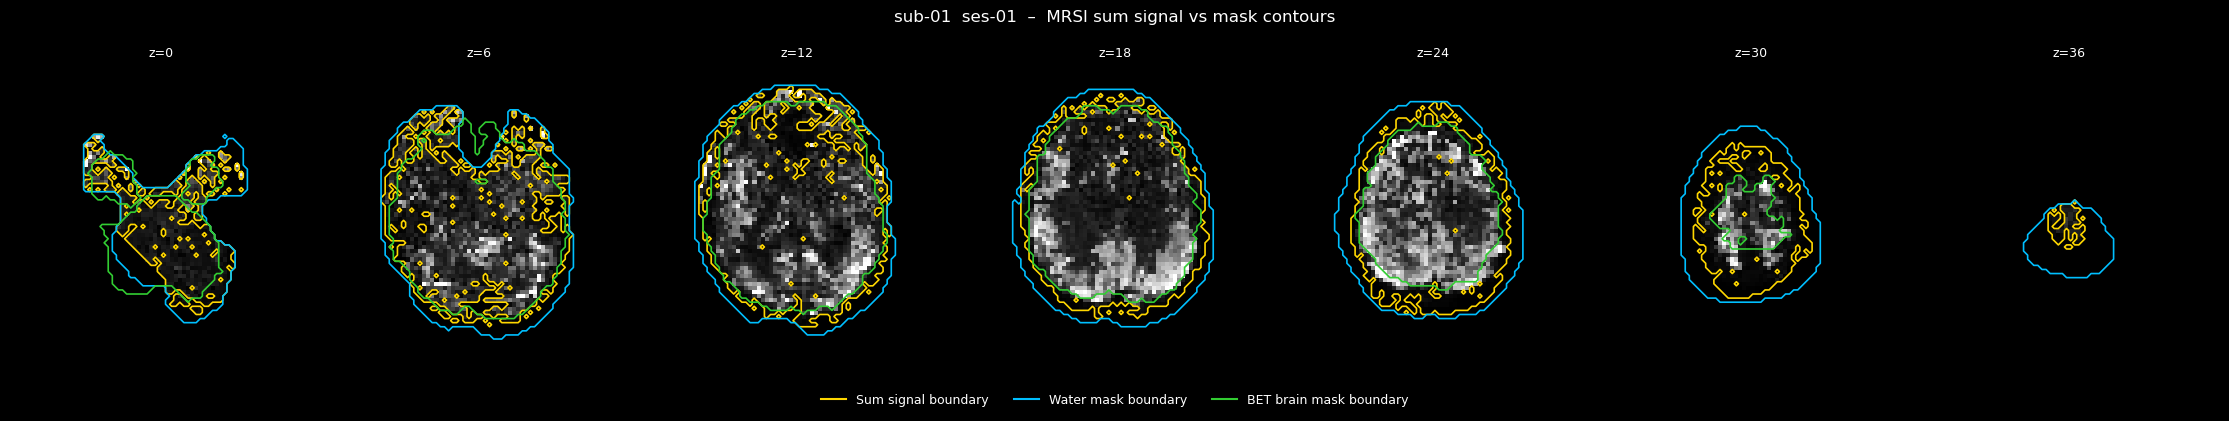

In [100]:
from main import bet_mask_reg_img, water_mask_img

plot_mrsi_sum_mask_contours(
    sum_img=sum_img,
    water_mask_img=water_mask_img,
    bet_mask_img=bet_mask_reg_img,
    subj=SUBJ,
    ses=SES,
)


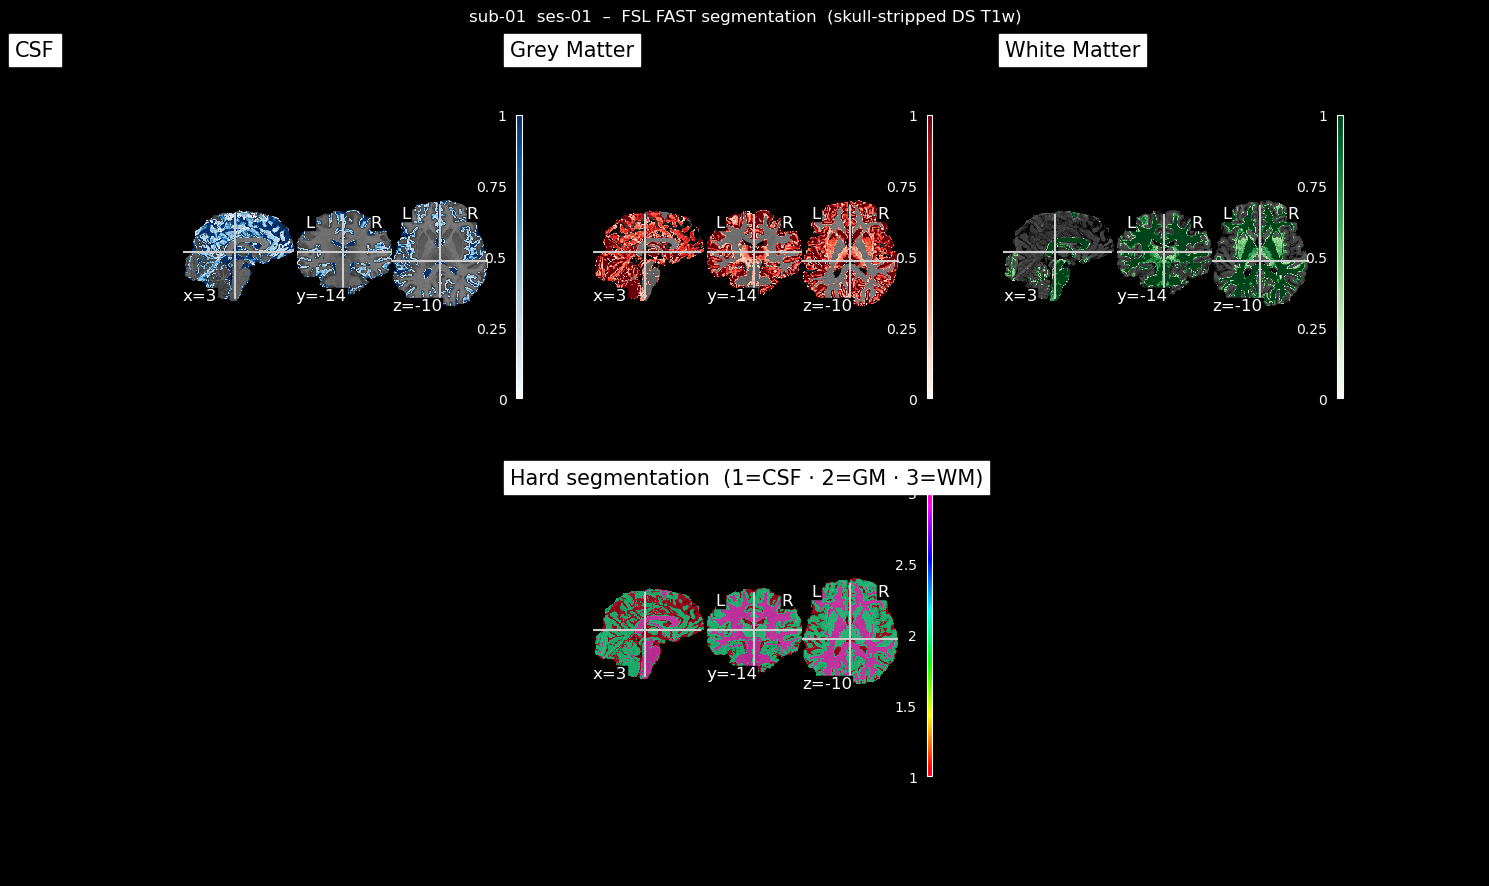


Tissue               Mean PVE   Volume (mL)
────────────────────────────────────────────
  CSF                   0.594        170.9 mL
  Grey Matter           0.718        525.6 mL
  White Matter          0.851        459.4 mL


In [104]:
from main import t1w_brain_img, seg_imgs
plot_segmentation(
    t1w_img=t1w_brain_img,
    seg_imgs=seg_imgs,
    subj=SUBJ,
    ses=SES,
)


────────────────────────────────────────────
  Mask comparison (MRSI grid)
────────────────────────────────────────────
  BET mask volume   :   1078.3 mL  ( 41038 vox)
  Water mask volume :   1686.2 mL  ( 64170 vox)
  Intersection      :   1064.7 mL  ( 40517 vox)
  BET-only voxels   :     13.7 mL  (   521 vox)
  Water-only voxels :    621.5 mL  ( 23653 vox)
  Dice coefficient  : 0.7702  (1.0 = identical)
  Jaccard index     : 0.6263
  Masks are identical : False
────────────────────────────────────────────

  ACTIVE mask for Reg 18 : sub-01_ses-01_acq-MRSIres_desc-BrainMask_T1w.nii.gz


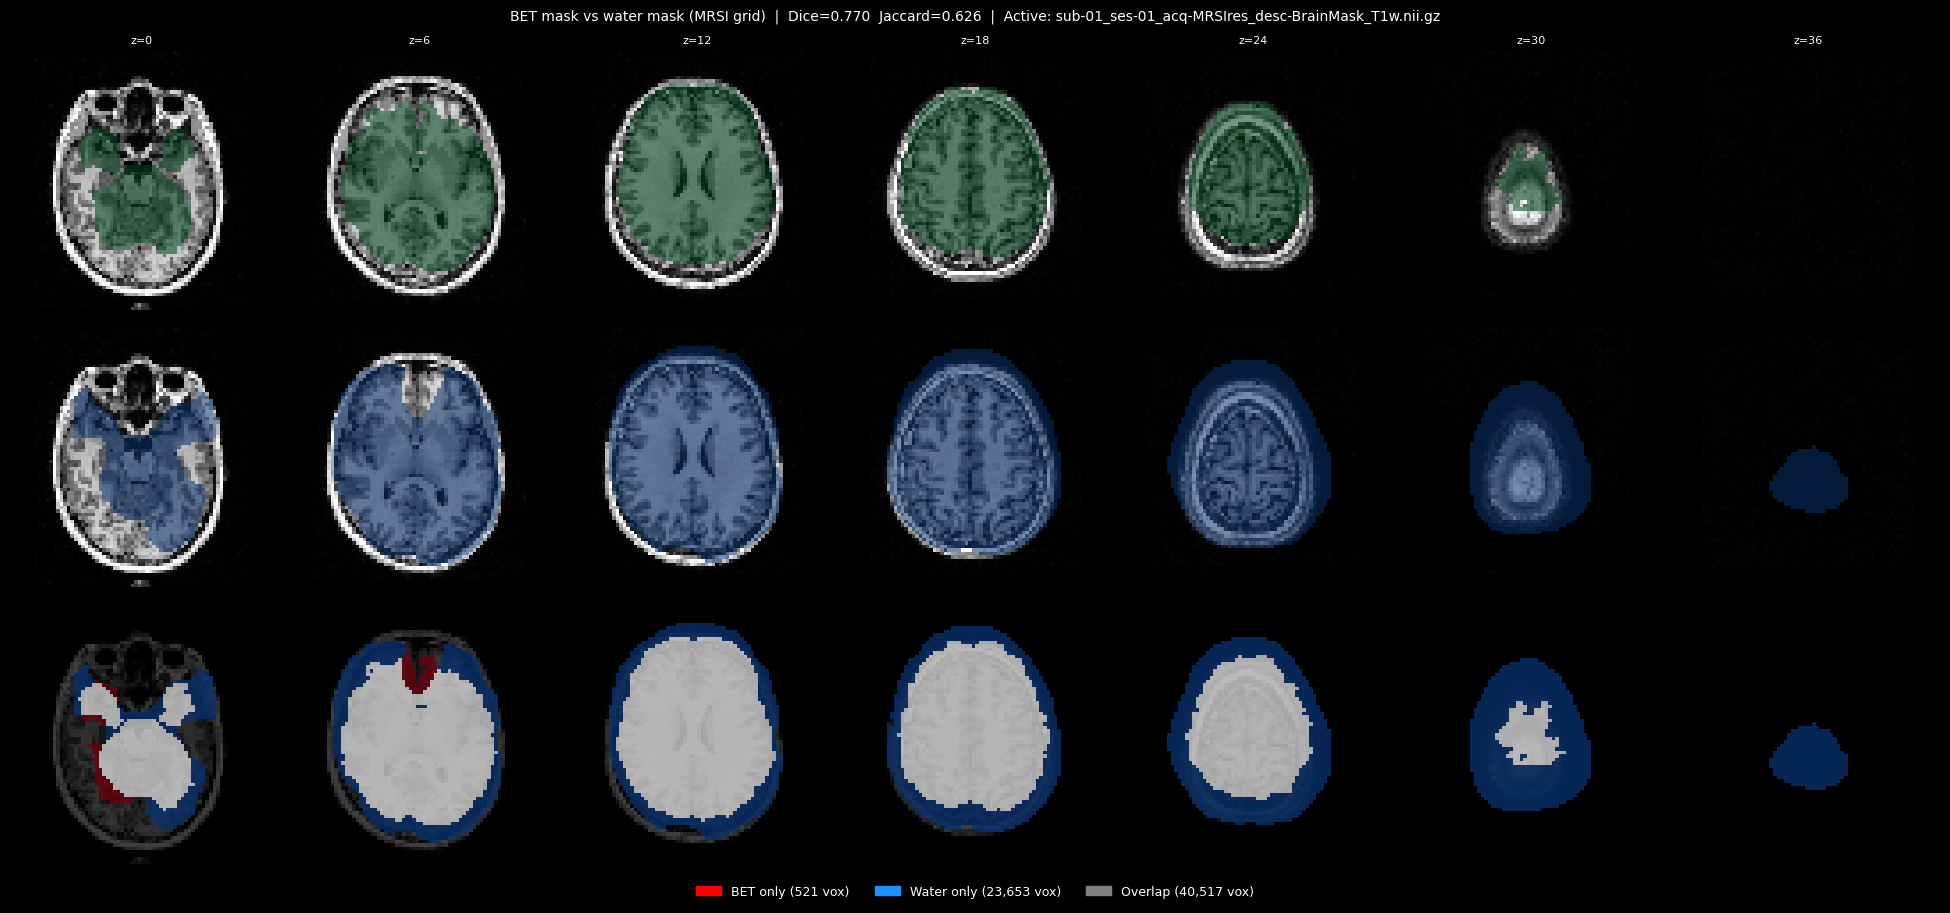

In [ ]:
from main import bet_mask_reg_img, freesurfer_mask_reg_img, T1W_BRAIN_MASK_DS_NAME


plot_mask_coverage_comparaison(
        bet_mask_img=bet_mask_reg_img,
        water_mask_img=water_mask_img,
        extra_mask_img=freesurfer_mask_reg_img,
        t1w_ds_img=t1w_ds_img,
        subj=SUBJ,
        ses=SES,
        active_mask_name=T1W_BRAIN_MASK_DS_NAME)


In [108]:
#from main import atlas_imgs
#plot_atlas_segmentation(
#    t1w_img=t1w_brain_img,
#    atlas_imgs=atlas_imgs,
#    subj=SUBJ,
#    ses=SES)
